# **EDA For Telco Customer Churn**


## *Contents*

1. Data Loading and First Look
2. Data Cleaning (hidden missing values, dropping useless columns)
3. Duplicates
4. Target Distribution and Class Imbalance
5. Univariate Analysis (numeric + categorical)
6. Bivariate Analysis (features vs target)
7. Multivariate Analysis (pairplot, grouped aggregations)
8. Correlation Heatmap
9. Outlier Detection (IQR and Z-score)
10. Skewness and Log Transform
11. Normality Tests
12. Statistical Tests (T-test, Chi-Square)
13. PCA Visualization
14. Class Imbalance Handling
15. Key Insights Summary

Binary classification: predict whether a customer will churn (leave) or not.

7043 rows, 21 columns. Mix of numeric and categorical features with hidden missing values, skewed distribution and class imbalance. 

In [1]:
import numpy as np
import os
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import ttest_ind, chi2_contingency, normaltest, shapiro
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

### Read The Data

In [2]:
df = pd.read_csv('data/raw/data.csv')
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


###  **Understanding the data**

In [3]:
# Data types and non-null counts
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [4]:
# Column names as a clean list
list(df.columns)

['customerID',
 'gender',
 'SeniorCitizen',
 'Partner',
 'Dependents',
 'tenure',
 'PhoneService',
 'MultipleLines',
 'InternetService',
 'OnlineSecurity',
 'OnlineBackup',
 'DeviceProtection',
 'TechSupport',
 'StreamingTV',
 'StreamingMovies',
 'Contract',
 'PaperlessBilling',
 'PaymentMethod',
 'MonthlyCharges',
 'TotalCharges',
 'Churn']

In [5]:
# Basic statistics for numeric columns
df.describe()

,SeniorCitizen,tenure,MonthlyCharges
count,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692
std,0.368612,24.559481,30.090047
min,0.000000,0.000000,18.250000
25%,0.000000,9.000000,35.500000
50%,0.000000,29.000000,70.350000
75%,0.000000,55.000000,89.850000
max,1.000000,72.000000,118.750000


From df.info():
- TotalCharges is currently stored as an object (string) rather than a float64, which indicates the presence of non-numeric entries—likely blank spaces or special characters. 
- MonthlyCharges is correctly formatted as float64, while tenure and SeniorCitizen are both int64, as expected. 
- customerID serves only as a unique identifier and does not contribute any predictive value, so it will be removed from the dataset.


## **Data Cleaning**


TotalCharges should be numeric but it is stored as a string. 

In [6]:
# Find non-numeric values in TotalCharges
mask = pd.to_numeric(df['TotalCharges'], errors='coerce').isna()
bad_rows = df[mask]

print("Number of bad rows:", mask.sum())
bad_rows

Number of bad rows: 11


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
488,4472-LVYGI,Female,0,Yes,Yes,0,No,No phone service,DSL,Yes,...,Yes,Yes,Yes,No,Two year,Yes,Bank transfer (automatic),52.55,,No
753,3115-CZMZD,Male,0,No,Yes,0,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,20.25,,No
936,5709-LVOEQ,Female,0,Yes,Yes,0,Yes,No,DSL,Yes,...,Yes,No,Yes,Yes,Two year,No,Mailed check,80.85,,No
1082,4367-NUYAO,Male,0,Yes,Yes,0,Yes,Yes,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,25.75,,No
1340,1371-DWPAZ,Female,0,Yes,Yes,0,No,No phone service,DSL,Yes,...,Yes,Yes,Yes,No,Two year,No,Credit card (automatic),56.05,,No
3331,7644-OMVMY,Male,0,Yes,Yes,0,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,19.85,,No
3826,3213-VVOLG,Male,0,Yes,Yes,0,Yes,Yes,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,25.35,,No
4380,2520-SGTTA,Female,0,Yes,Yes,0,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,20.00,,No
5218,2923-ARZLG,Male,0,Yes,Yes,0,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,One year,Yes,Mailed check,19.70,,No
6670,4075-WKNIU,Female,0,Yes,Yes,0,Yes,Yes,DSL,No,...,Yes,Yes,Yes,No,Two year,No,Mailed check,73.35,,No


There are 11 rows where TotalCharges contains a blank space (" ") instead of a numeric value. On inspection, all of these rows have tenure = 0, indicating they are newly signed customers who have not yet been billed.\
**This explains why their total charges are missing. There are two possible approaches: remove these 11 rows (which represent only about 0.15% of the dataset) or replace the missing values with 0. Given the context, imputing with 0 is more appropriate, as customers with zero tenure would logically have zero total charges.**

#### Check customerID

customerID is a unique identifier for each customer. It has no relationship with churn. Every value is different so the model cannot learn any pattern from it. Keeping it would just add noise.

#### Check for remaining missing values

In [7]:
# Missing values check
print("Missing values per column:")
print(df.isnull().sum())
print()
print("Total missing:", df.isnull().sum().sum())

Missing values per column:
customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

Total missing: 0


### Duplicates

In [8]:
# Check for duplicate rows
duplicated_rows = df[df.duplicated()]
print(duplicated_rows)

Empty DataFrame
Columns: [customerID, gender, SeniorCitizen, Partner, Dependents, tenure, PhoneService, MultipleLines, InternetService, OnlineSecurity, OnlineBackup, DeviceProtection, TechSupport, StreamingTV, StreamingMovies, Contract, PaperlessBilling, PaymentMethod, MonthlyCharges, TotalCharges, Churn]
Index: []

[0 rows x 21 columns]


## **Identify Column Types**

Before starting EDA, we will separate numeric and categorical columns. This makes it easy to loop through them for plots and tests.

In [9]:
# Note: SeniorCitizen is stored as int (0/1) but it is actually categorical
# We convert it to string so it is treated as categorical

df['SeniorCitizen'] = df['SeniorCitizen'].map({0: 'No', 1: 'Yes'})

# Now separate
cat_cols = df.select_dtypes(include='object').columns.tolist()
num_cols = df.select_dtypes(include=[np.number]).columns.tolist()

# Remove target from feature lists
cat_cols = [c for c in cat_cols if c != 'Churn']

print("Categorical features:", cat_cols)
print("Count:", len(cat_cols))
print()
print("Numeric features:", num_cols)
print("Count:", len(num_cols))

Categorical features: ['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod', 'TotalCharges']
Count: 18

Numeric features: ['tenure', 'MonthlyCharges']
Count: 2


SeniorCitizen is encoded as 0 and 1, but it represents a binary category rather than a true numerical variable. Specifically, it indicates whether a customer is a senior citizen (Yes or No), not a quantity or measurement.

If left as an integer, some models—particularly linear models—may interpret it as a continuous numeric feature, implicitly assigning mathematical meaning to the difference between 0 and 1. Converting it to a categorical variable makes its role in the dataset clearer and ensures it is treated appropriately during analysis.

## **Target Distribution (Imbalance Check)**

Target value counts:
Churn
No     5174
Yes    1869
Name: count, dtype: int64

Target proportions:
Churn
No     0.735
Yes    0.265
Name: proportion, dtype: float64


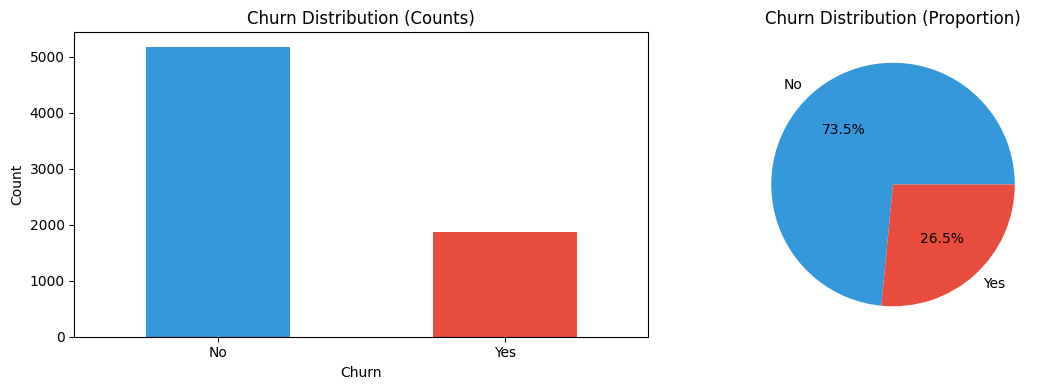


Imbalance ratio: 2.77:1


In [10]:
# Target distribution
print("Target value counts:")
print(df['Churn'].value_counts())
print()
print("Target proportions:")
print(df['Churn'].value_counts(normalize=True).round(3))

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Count plot
df['Churn'].value_counts().plot(kind='bar', ax=axes[0], color=['#3498db', '#e74c3c'])
axes[0].set_title('Churn Distribution (Counts)')
axes[0].set_ylabel('Count')
axes[0].tick_params(axis='x', rotation=0)

# Pie chart
df['Churn'].value_counts().plot(kind='pie', ax=axes[1], autopct='%1.1f%%',
                                 colors=['#3498db', '#e74c3c'])
axes[1].set_ylabel('')
axes[1].set_title('Churn Distribution (Proportion)')

plt.tight_layout()
plt.show()

# Imbalance ratio
majority = df['Churn'].value_counts().max()
minority = df['Churn'].value_counts().min()
print(f"\nImbalance ratio: {majority/minority:.2f}:1")

About 73% of customers did not churn and 27% did churn. The imbalance ratio is roughly 2.7:1.

This is moderate imbalance. Not severe but enough to affect model performance if we only look at accuracy.

For example, a model that always predicts "No Churn" would get 73% accuracy without learning anything useful.


#### Based on this, we can understand what imbalance ratio is problematic

| Ratio | Severity | Action |
|---|---|---|
| Below 2:1 | Generally fine | No special handling needed |
| 2:1 to 5:1 | Moderate | Use class weights, stratified sampling |
| 5:1 to 20:1 | Significant | SMOTE, undersampling, focal loss |
| Above 20:1 | Severe | Aggressive resampling, anomaly detection approach

---

## **Univariate Analysis**

#### Explore each feature to further understand each one
---

### Numeric Features

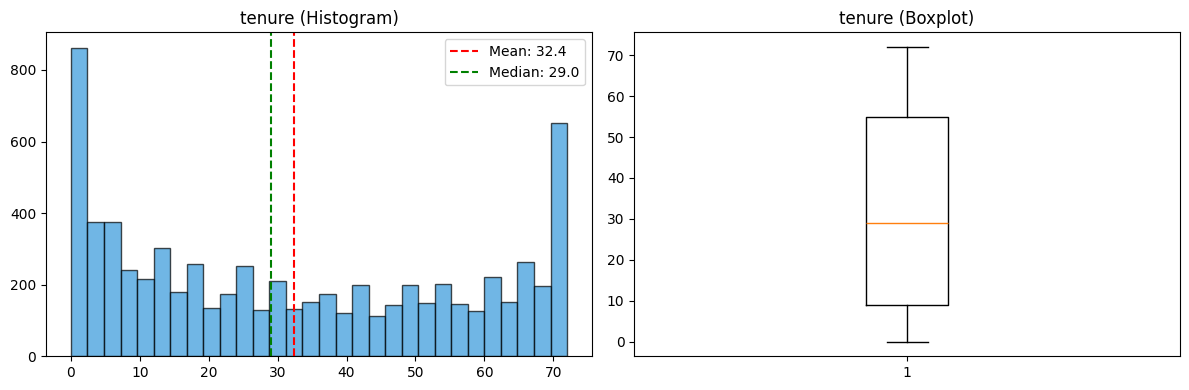

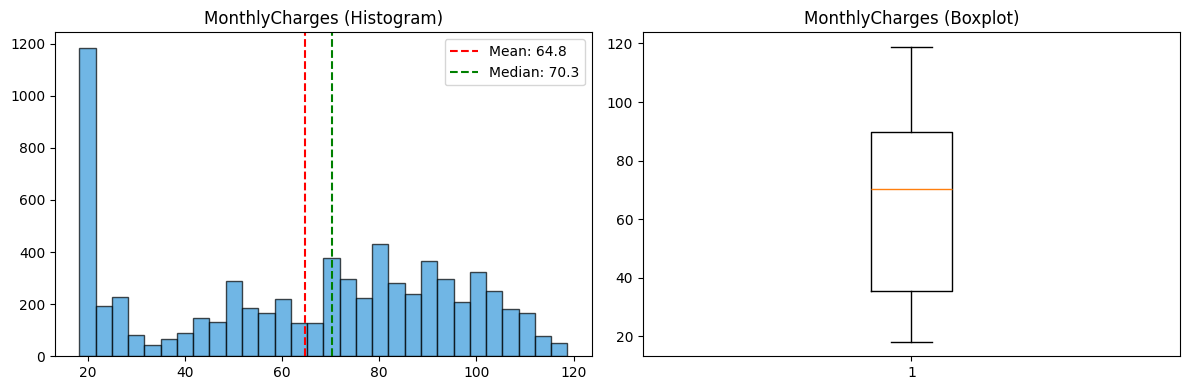

In [11]:
# Histograms for numeric features
for col in num_cols:
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))

    # Histogram with mean and median lines
    axes[0].hist(df[col], bins=30, color='#3498db', edgecolor='black', alpha=0.7)
    axes[0].axvline(df[col].mean(), color='red', linestyle='--', label=f'Mean: {df[col].mean():.1f}')
    axes[0].axvline(df[col].median(), color='green', linestyle='--', label=f'Median: {df[col].median():.1f}')
    axes[0].set_title(f'{col} (Histogram)')
    axes[0].legend()

    # Boxplot
    axes[1].boxplot(df[col], vert=True)
    axes[1].set_title(f'{col} (Boxplot)')

    plt.tight_layout()
    plt.show()

In [12]:
# Extended describe with extra percentiles
print("Extended Statistics:")
print(df[num_cols].describe(percentiles=[0.01, 0.05, 0.25, 0.5, 0.75, 0.95, 0.99]).round(2))

Extended Statistics:
        tenure  MonthlyCharges
count  7043.00         7043.00
mean     32.37           64.76
std      24.56           30.09
min       0.00           18.25
1%        1.00           19.20
5%        1.00           19.65
25%       9.00           35.50
50%      29.00           70.35
75%      55.00           89.85
95%      72.00          107.40
99%      72.00          114.73
max      72.00          118.75


#### **Observations**

- tenure: The distribution appears bimodal, with one cluster around 0–5 months (new customers) and another around 70+ months (long-term customers). There are relatively fewer customers in the mid-range, which aligns with the pattern that customers tend to either churn early or remain for a long time.

- MonthlyCharges: Values are spread across the full range without noticeable outliers, giving it a fairly uniform distribution.

- TotalCharges: The distribution is strongly right-skewed. Most customers have low total charges—primarily newer customers—while a smaller group of long-term customers accumulates much higher totals. The zero values correspond to new customers whose charges were imputed earlier.



| Condition | Meaning |
|---|---|
| mean > median | Right skew (tail stretches to the right) |
| mean < median | Left skew (tail stretches to the left) |
| mean is close to median | Roughly symmetric |



### Categorical Features

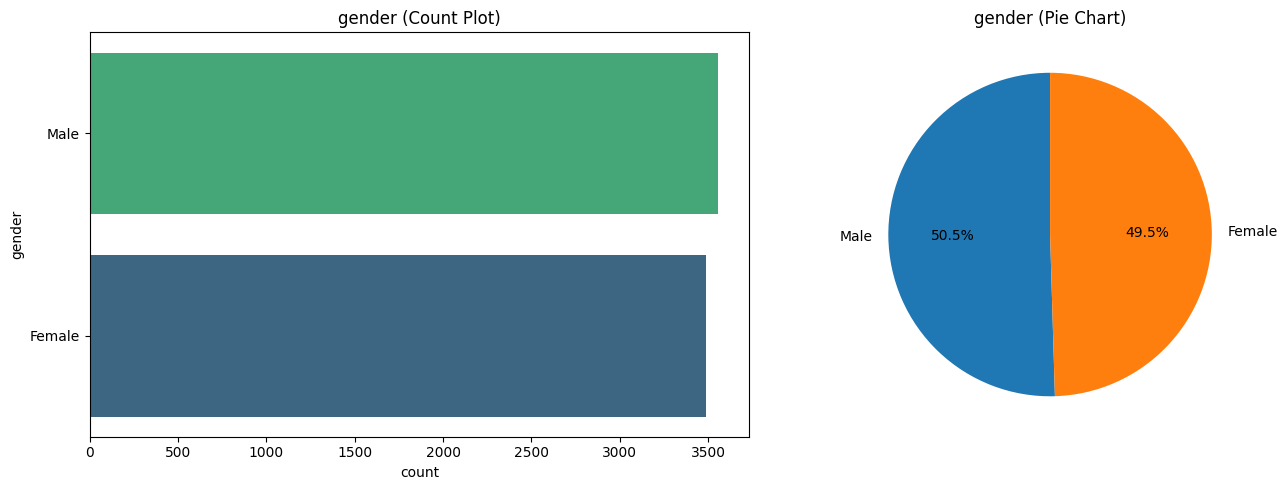

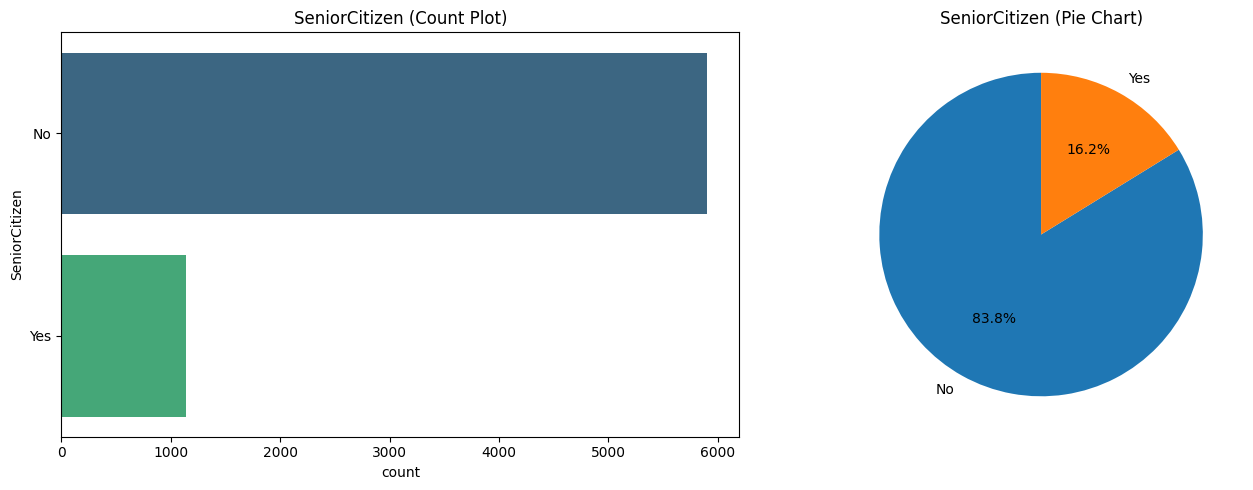

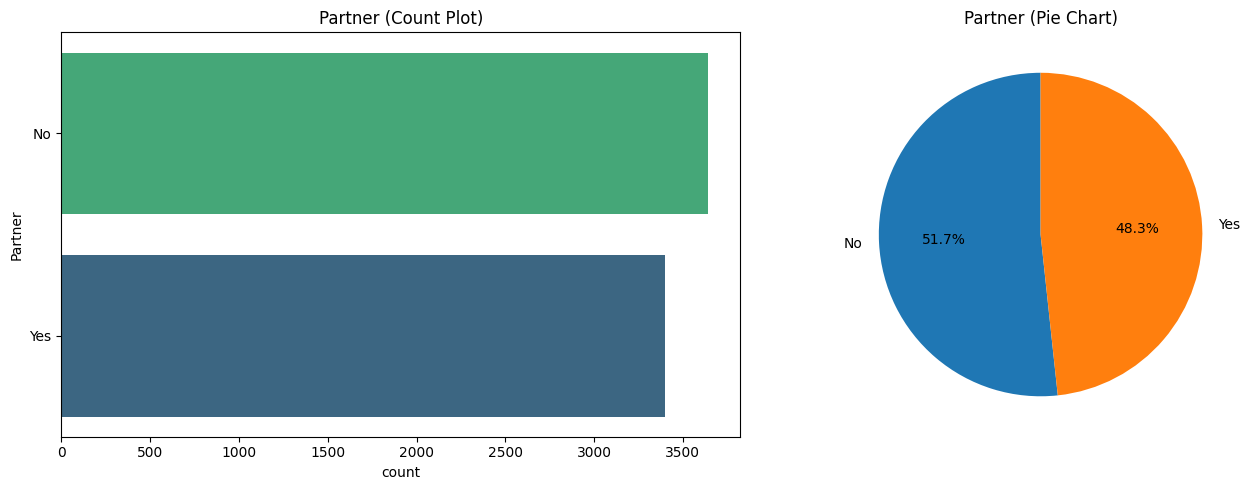

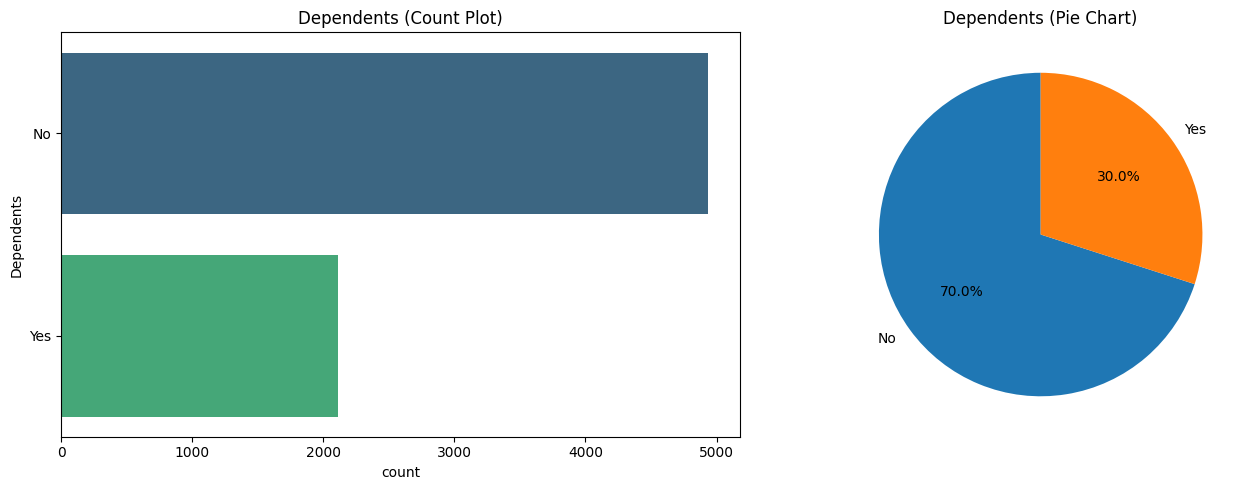

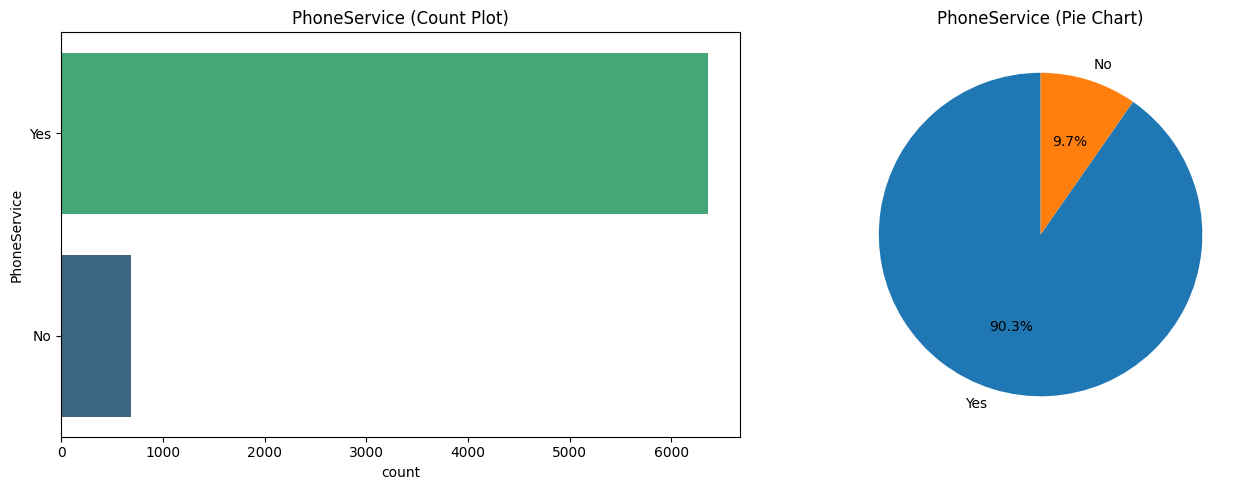

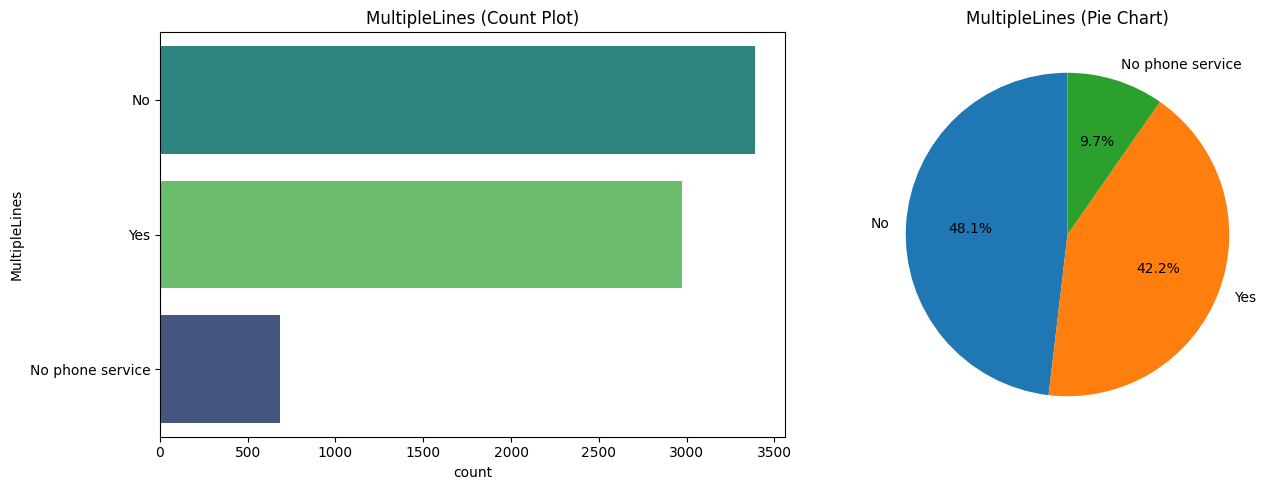

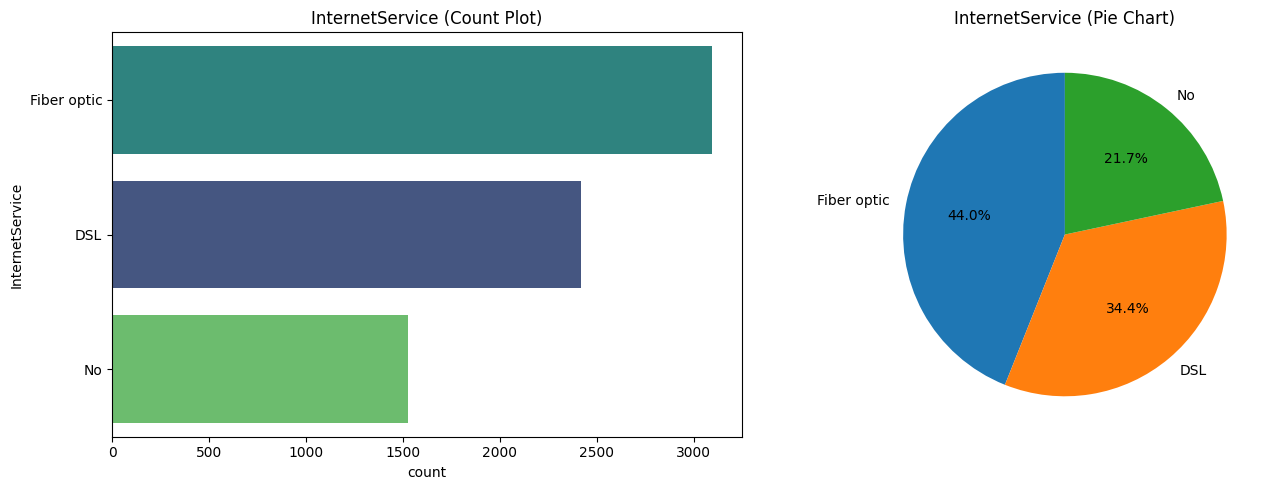

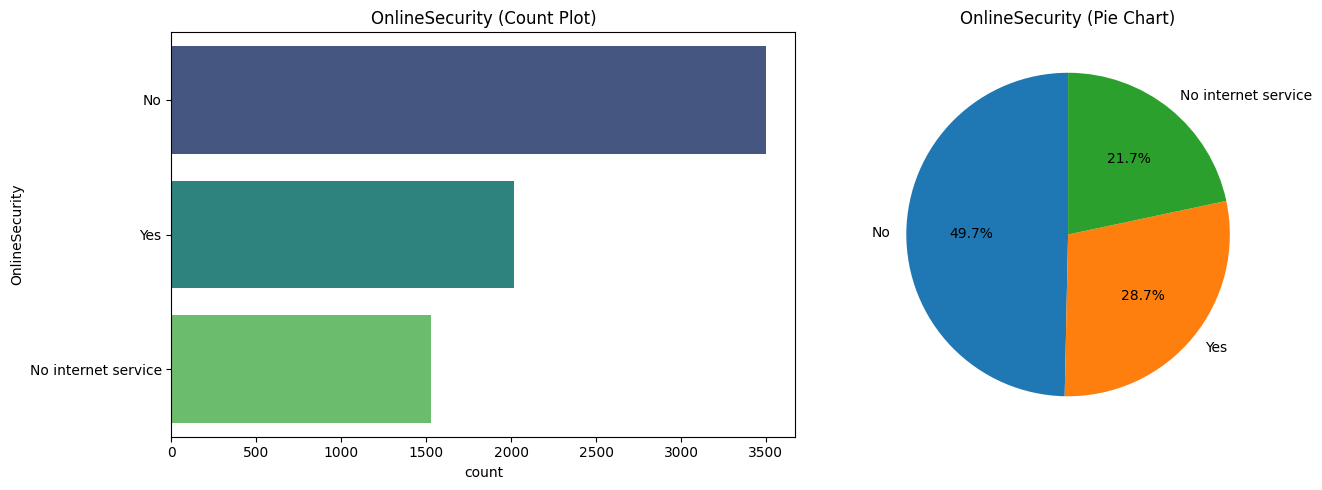

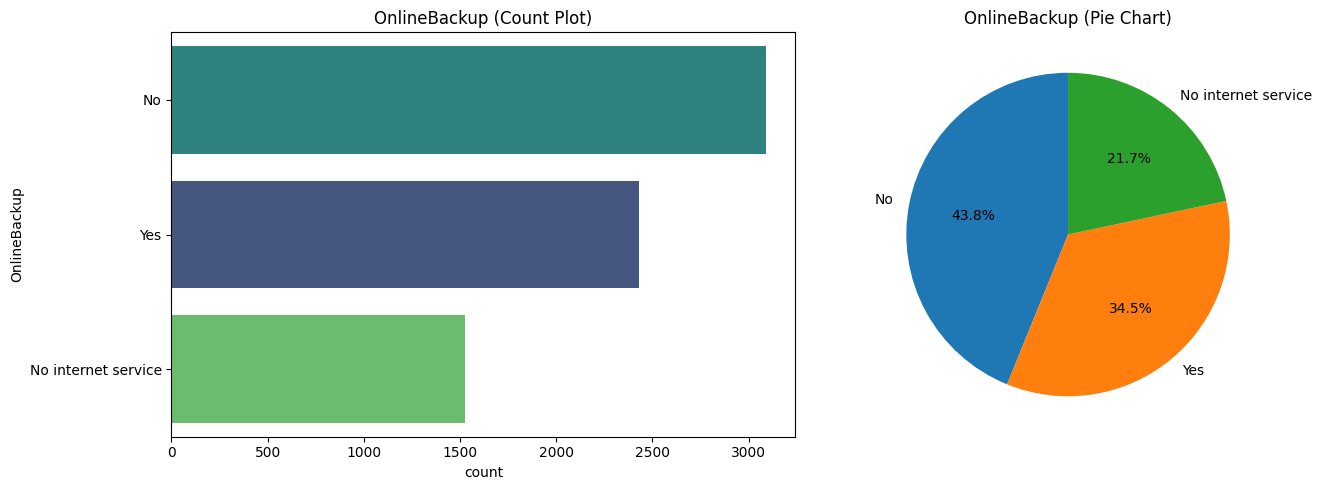

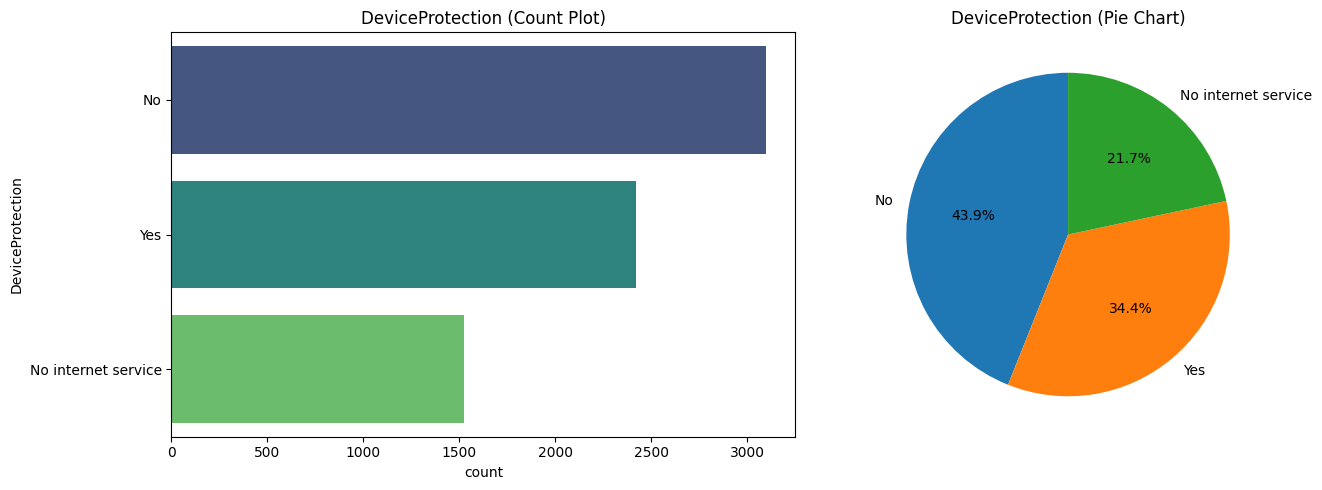

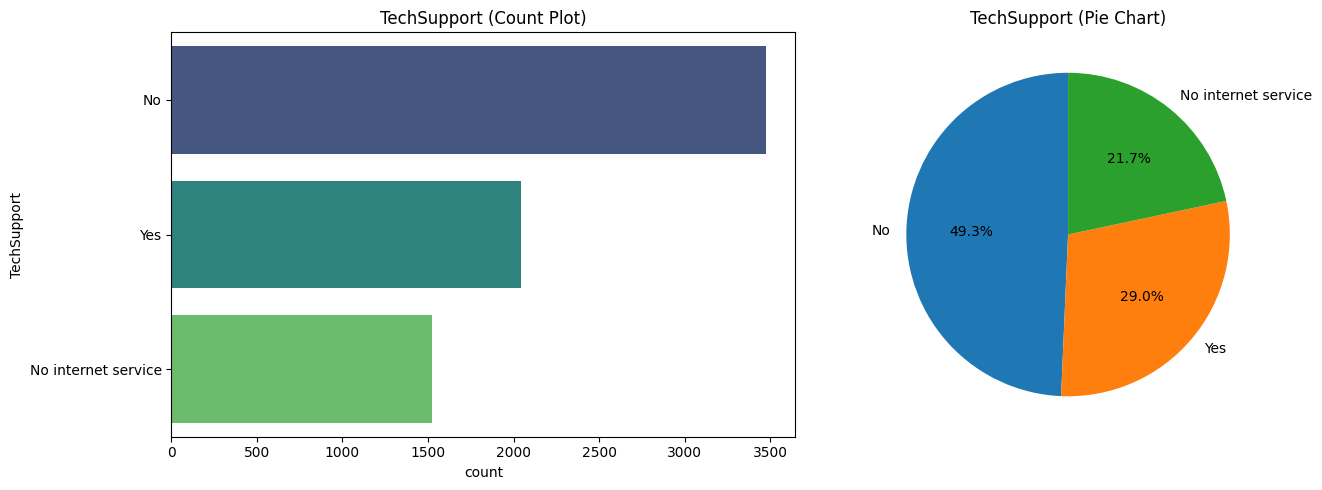

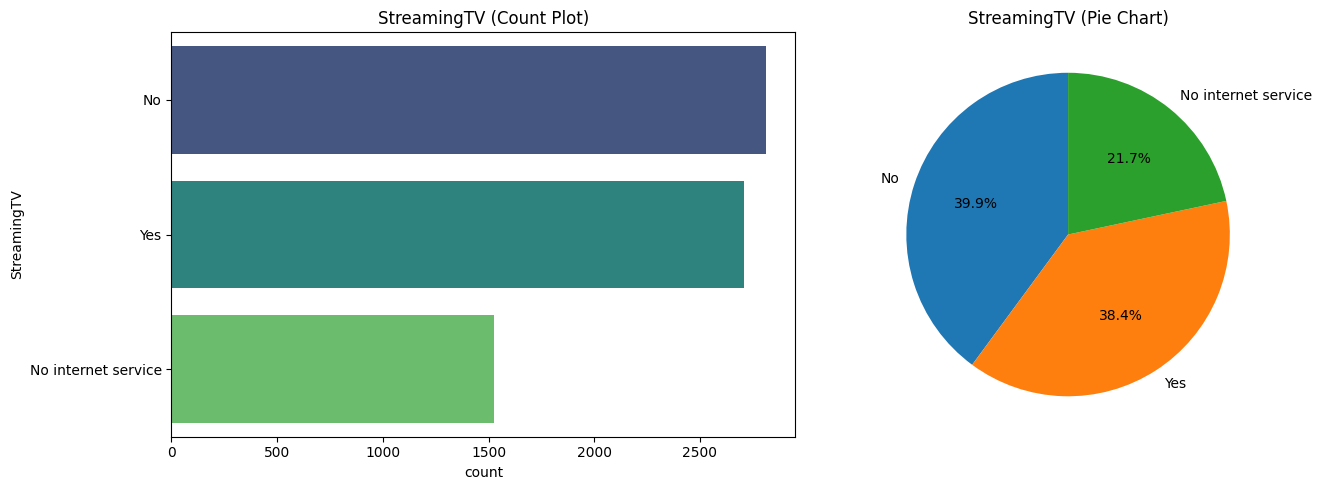

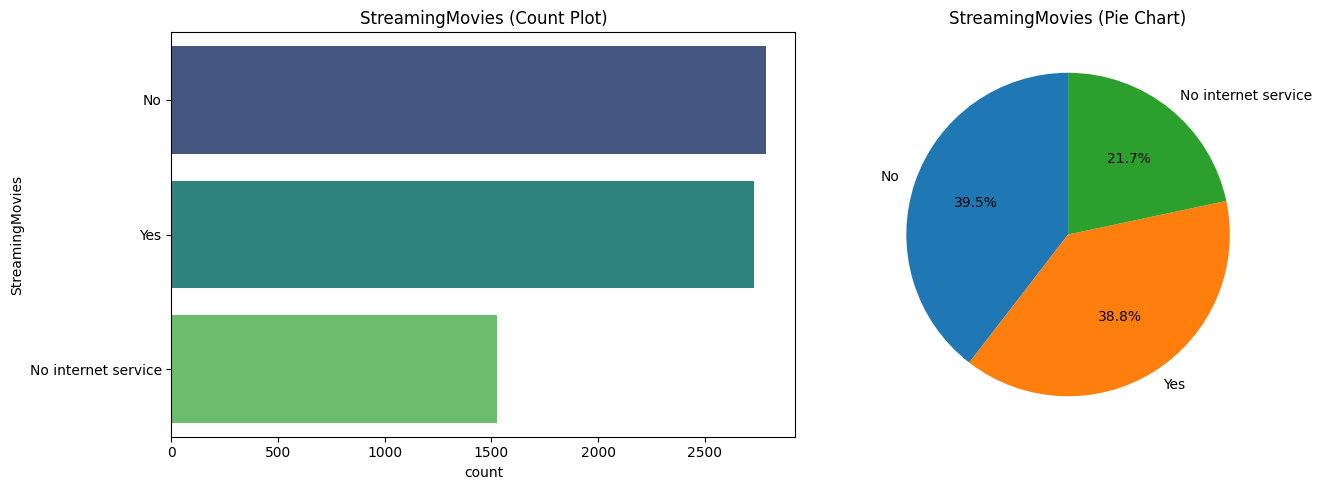

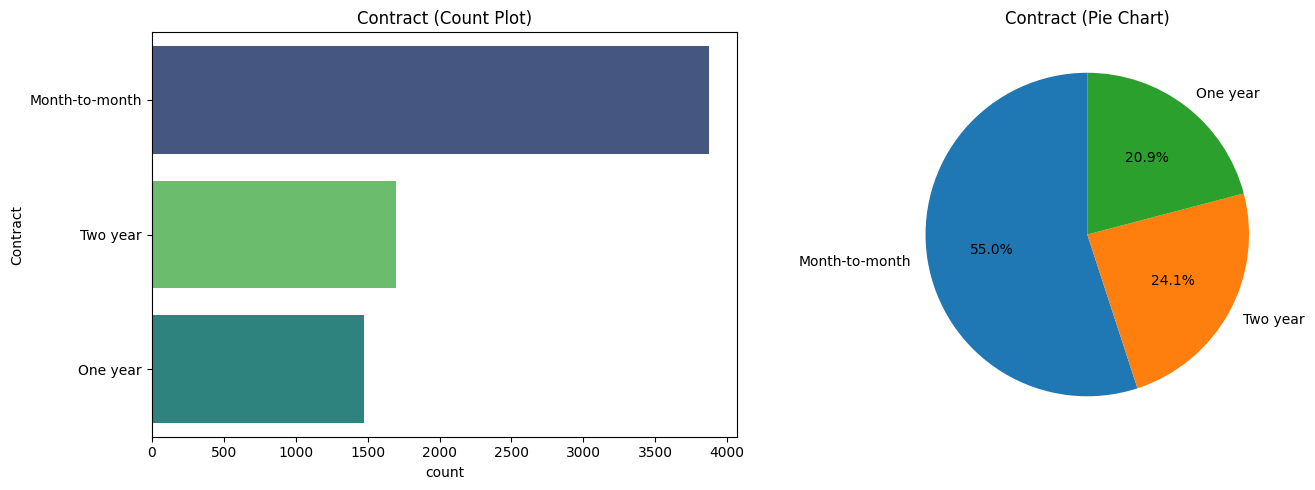

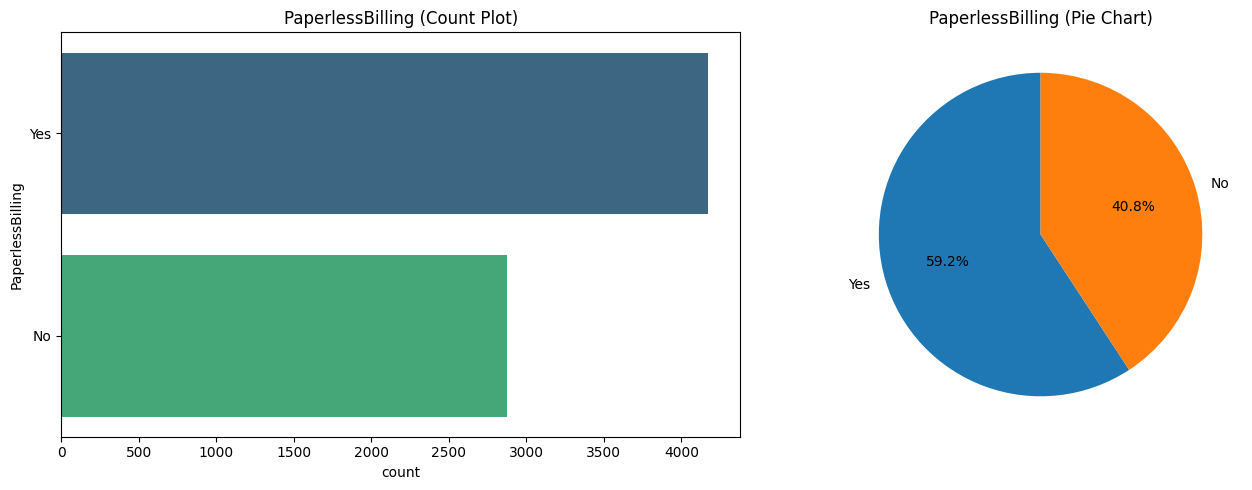

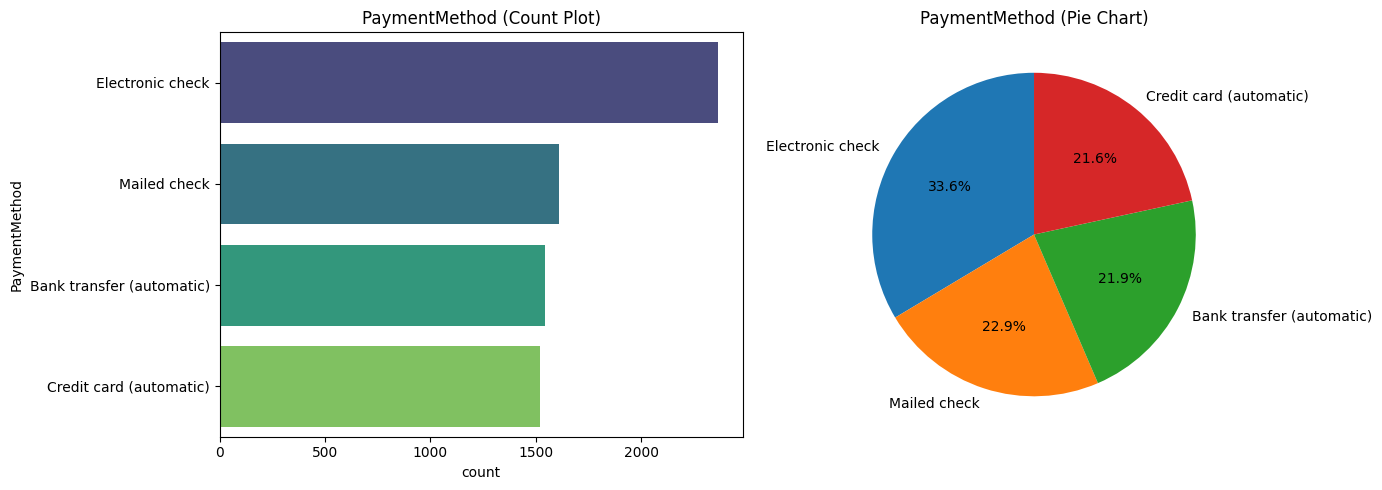

In [38]:
cat_cols = [col for col in cat_cols if col not in ['customerID', 'TotalCharges']] # Remove 'customerID' temporarily as it is an identifier, and 'TotalCharges' as it is numeric but stored as object

for col in cat_cols:
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    # Count plot
    order = df[col].value_counts().index
    sns.countplot(
        data=df,
        y=col,
        order=order,
        ax=axes[0],
        hue=col,
        palette='viridis',
        legend=False
    )
    axes[0].set_title(f'{col} (Count Plot)')

    # Pie chart
    counts = df[col].value_counts()
    if len(counts) > 8:
        top = counts.head(7)
        top['Other'] = counts.iloc[7:].sum()
        counts = top

    counts.plot(
        kind='pie',
        ax=axes[1],
        autopct='%1.1f%%',
        startangle=90
    )
    axes[1].set_title(f'{col} (Pie Chart)')
    axes[1].set_ylabel('')

    plt.tight_layout()
    plt.show()                                                                                                                              

In [39]:
# Cardinality check (how many unique values per categorical feature)
print("Cardinality of categorical features:")
print("-" * 35)
for col in cat_cols:
    print(f"  {col:20s}: {df[col].nunique()} unique values")

Cardinality of categorical features:
-----------------------------------
  gender              : 2 unique values
  SeniorCitizen       : 2 unique values
  Partner             : 2 unique values
  Dependents          : 2 unique values
  PhoneService        : 2 unique values
  MultipleLines       : 3 unique values
  InternetService     : 3 unique values
  OnlineSecurity      : 3 unique values
  OnlineBackup        : 3 unique values
  DeviceProtection    : 3 unique values
  TechSupport         : 3 unique values
  StreamingTV         : 3 unique values
  StreamingMovies     : 3 unique values
  Contract            : 3 unique values
  PaperlessBilling    : 2 unique values
  PaymentMethod       : 4 unique values


#### **Observations**

- gender is balanced (roughly 50-50). Not likely to be very predictive.
- Most customers have PhoneService (Yes). Low variance feature.
- InternetService has 3 categories. "No internet" customers exist.
- Several features (OnlineSecurity, OnlineBackup, TechSupport, etc.) have "No internet service" as a category. This is redundant with InternetService = No. Good to know for feature engineering.
- Contract type is important. Most customers are on month-to-month contracts.
- PaymentMethod has 4 categories with reasonable distribution.


---

## Bivariate Analysis


### Numeric Features vs Target

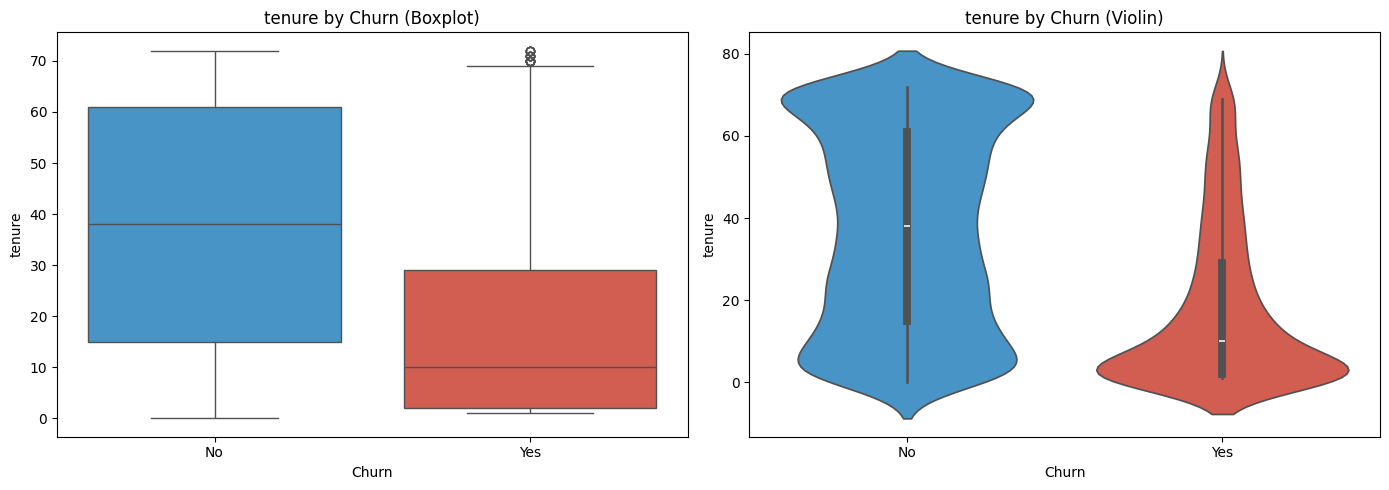

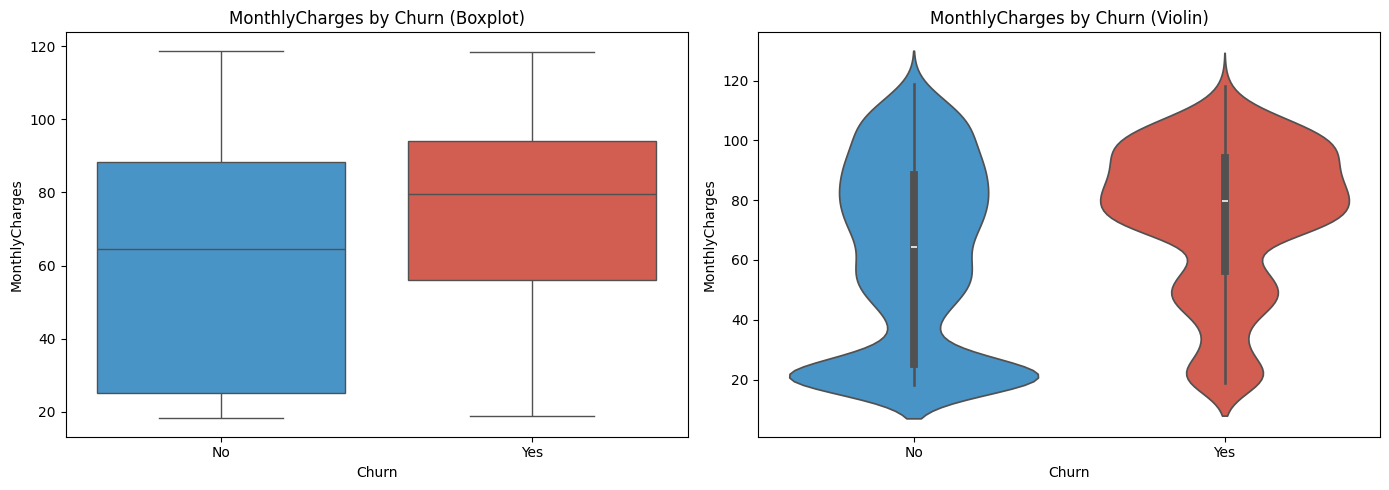

In [43]:
for col in num_cols:
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    # Boxplot
    sns.boxplot(
        data=df,
        x='Churn',
        y=col,
        ax=axes[0],
        hue='Churn',
        palette=['#3498db', '#e74c3c'],
        legend=False
    )
    axes[0].set_title(f'{col} by Churn (Boxplot)')

    # Violin plot
    sns.violinplot(
        data=df,
        x='Churn',
        y=col,
        ax=axes[1],
        hue='Churn',
        palette=['#3498db', '#e74c3c'],
        legend=False
    )
    axes[1].set_title(f'{col} by Churn (Violin)')

    plt.tight_layout()
    plt.show()

In [44]:
# Mean comparison table
group_stats = df.groupby('Churn')[num_cols].mean()
group_stats = group_stats.T
group_stats.columns = ['No_Churn_Mean', 'Yes_Churn_Mean']
group_stats['Difference'] = group_stats['Yes_Churn_Mean'] - group_stats['No_Churn_Mean']
print("Mean values by Churn class:")
print(group_stats.round(2))

Mean values by Churn class:
                No_Churn_Mean  Yes_Churn_Mean  Difference
tenure                  37.57           17.98      -19.59
MonthlyCharges          61.27           74.44       13.18


#### Key Patterns

**tenure**: Customers who churn have much lower tenure (average ~18 months) compared to those who stay (~38 months). This makes sense. New customers are more likely to leave. Long-term customers are already committed.

**MonthlyCharges**: Churned customers pay higher monthly charges on average. This suggests that customers on expensive plans are more likely to leave. Maybe they feel they are not getting value for the price.

**TotalCharges**: Churned customers have lower total charges. This is connected to tenure. They leave early so they have not accumulated much total charge.

---

#### Reading Boxplot vs Violin

| Plot | What It Shows | When It Helps |
|---|---|---|
| Boxplot | Median, quartiles, outliers | Quick comparison of center and spread |
| Violin | Full distribution shape | See if distribution is bimodal or skewed within a group |

---

### Categorical Features vs Target

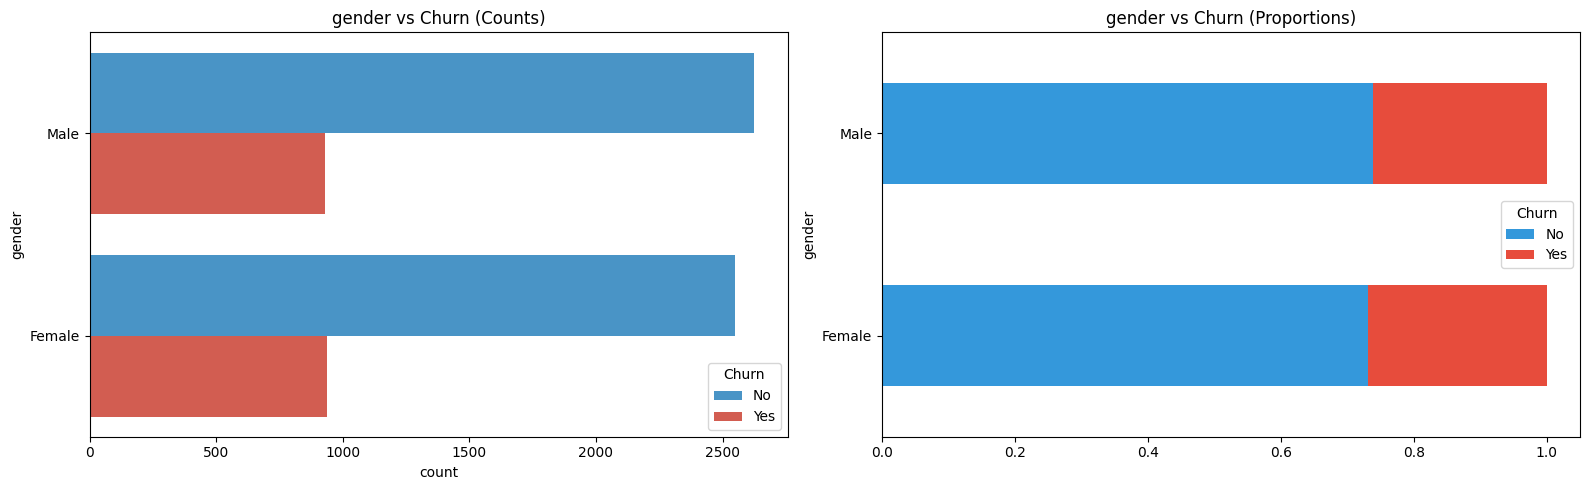

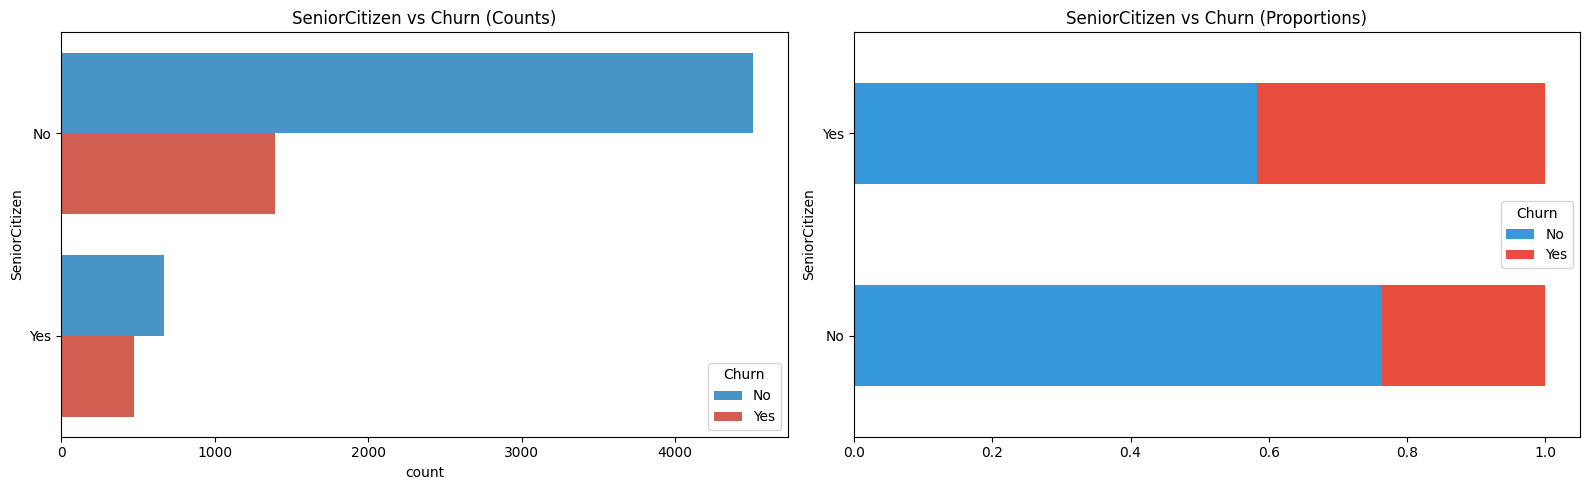

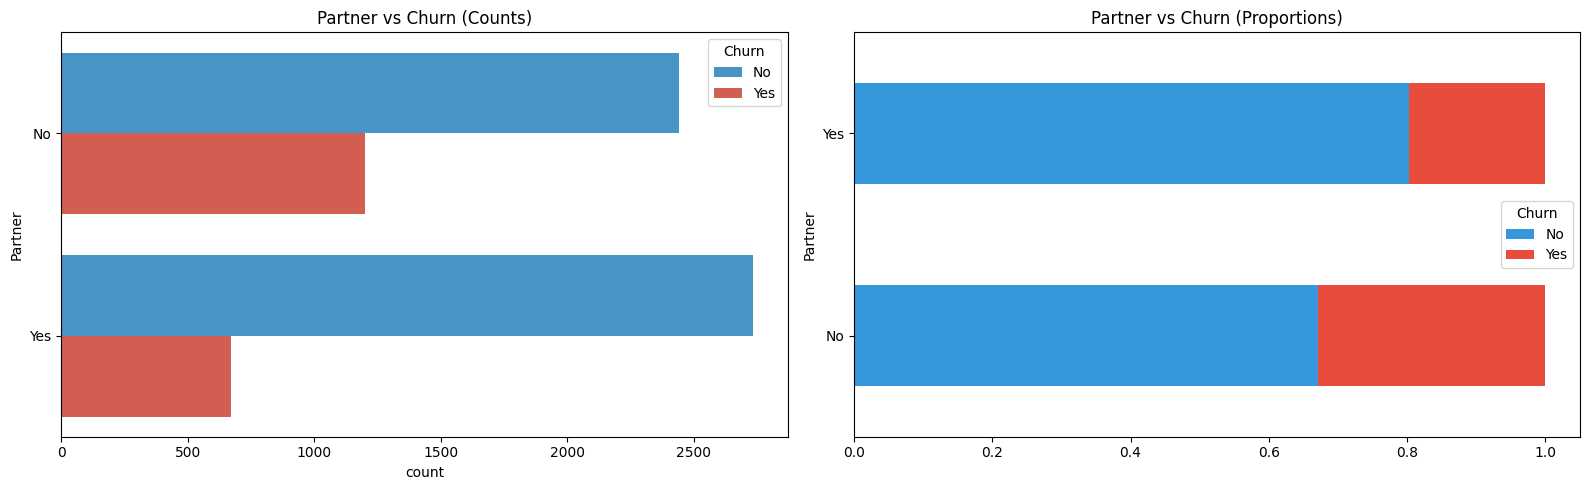

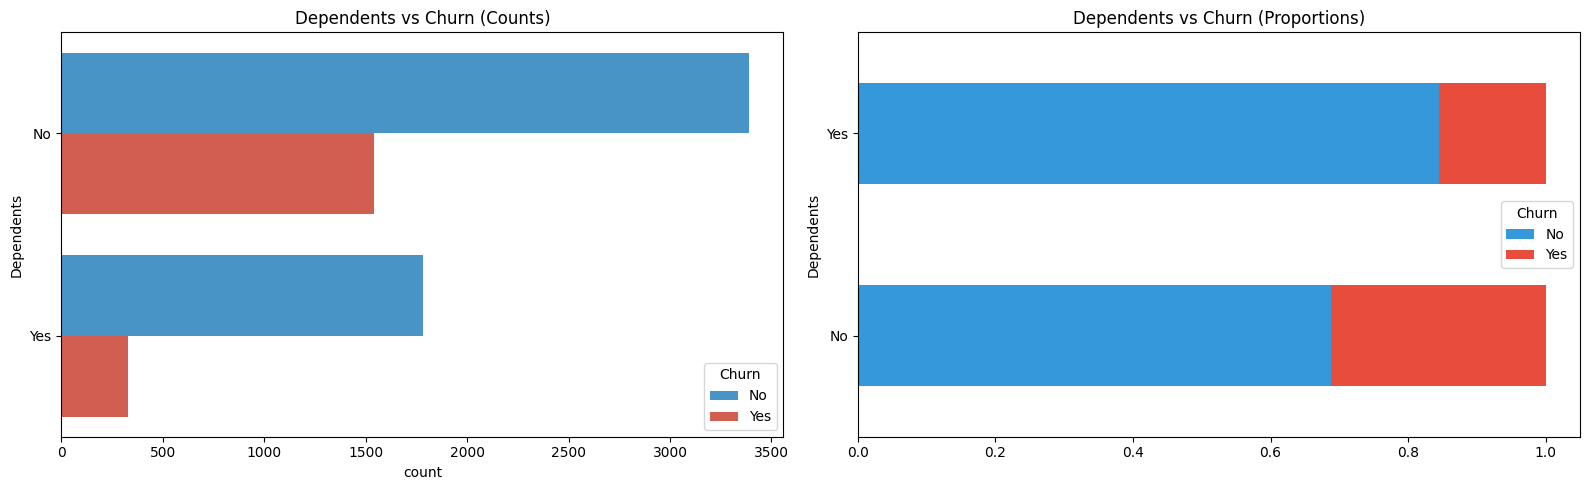

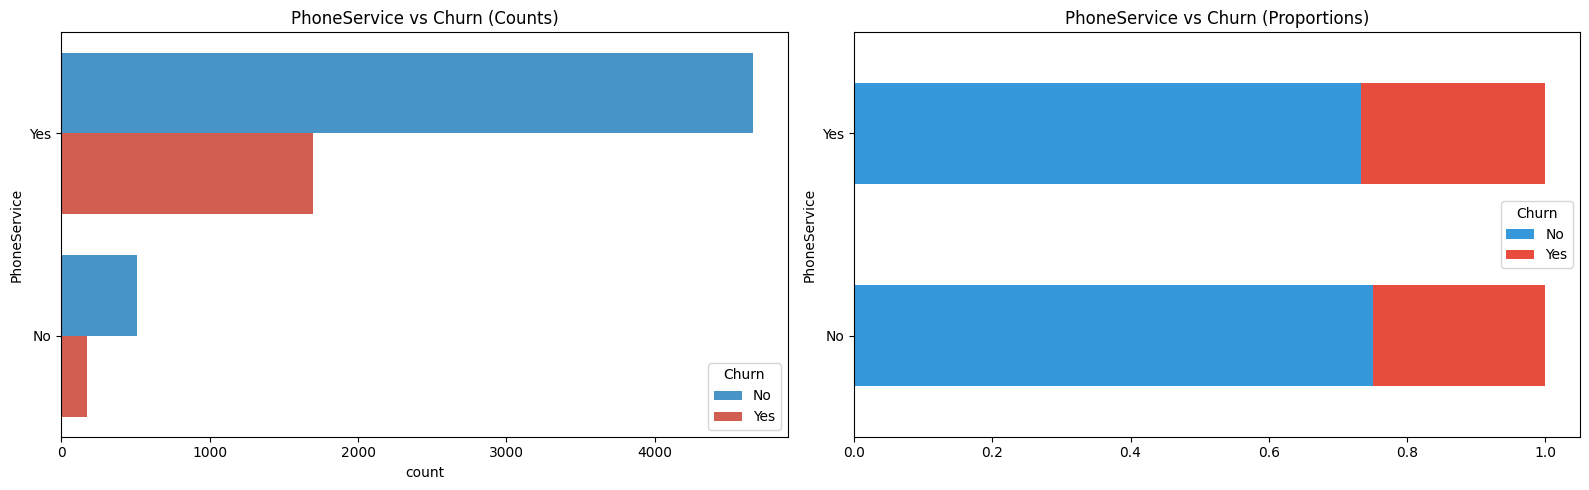

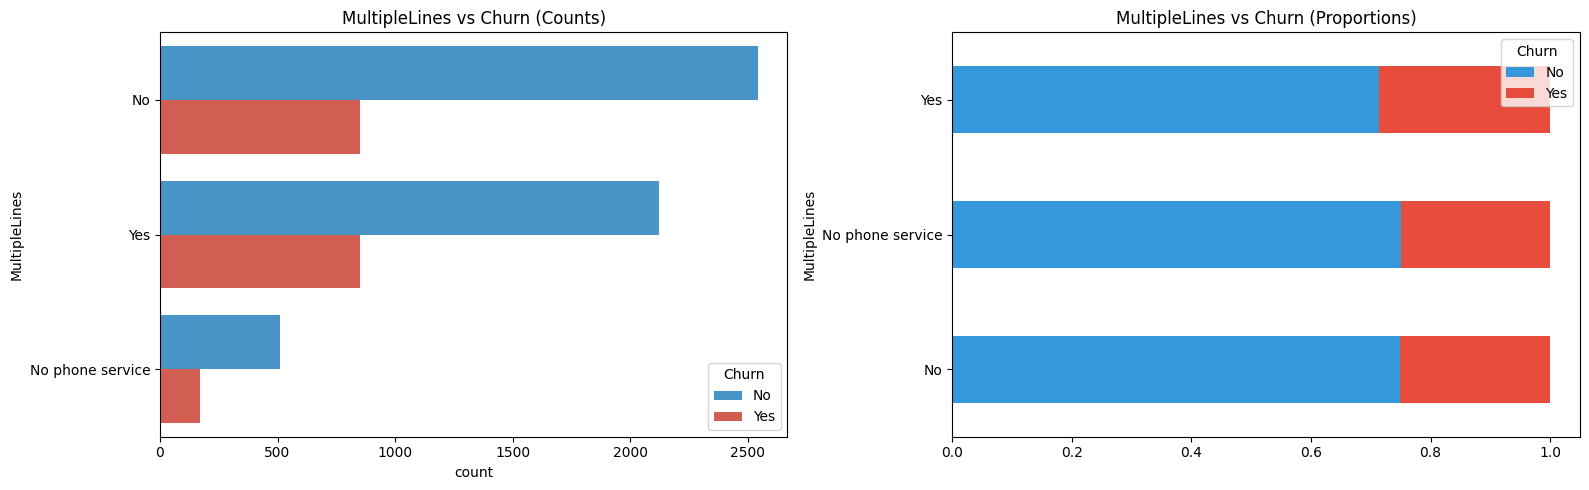

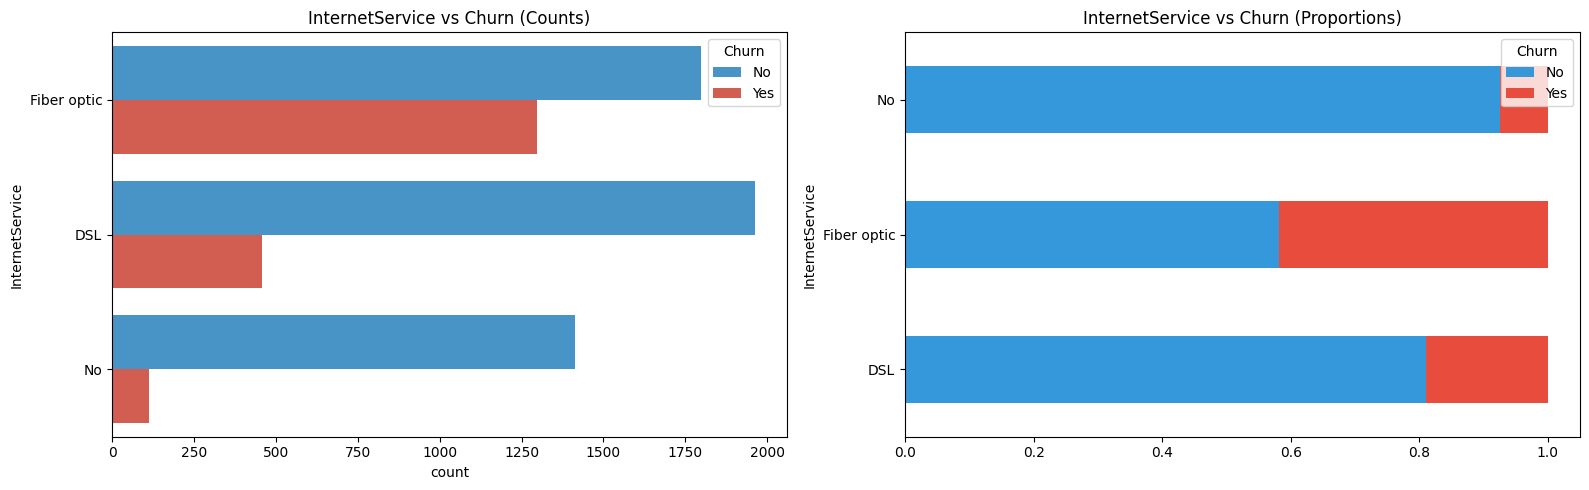

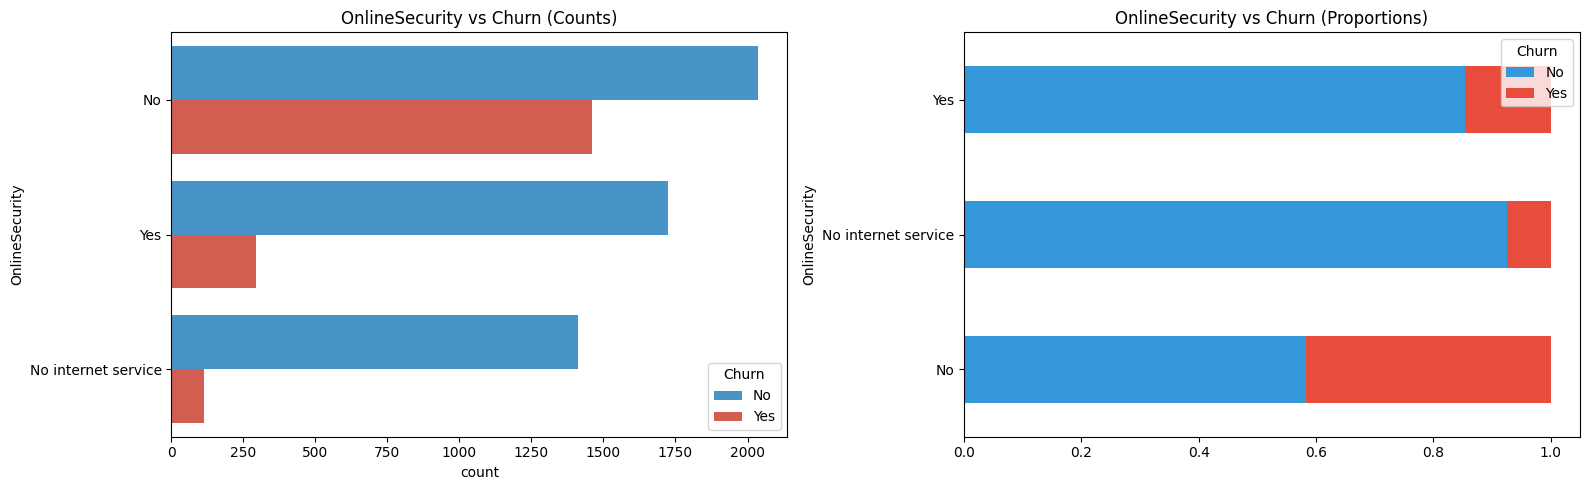

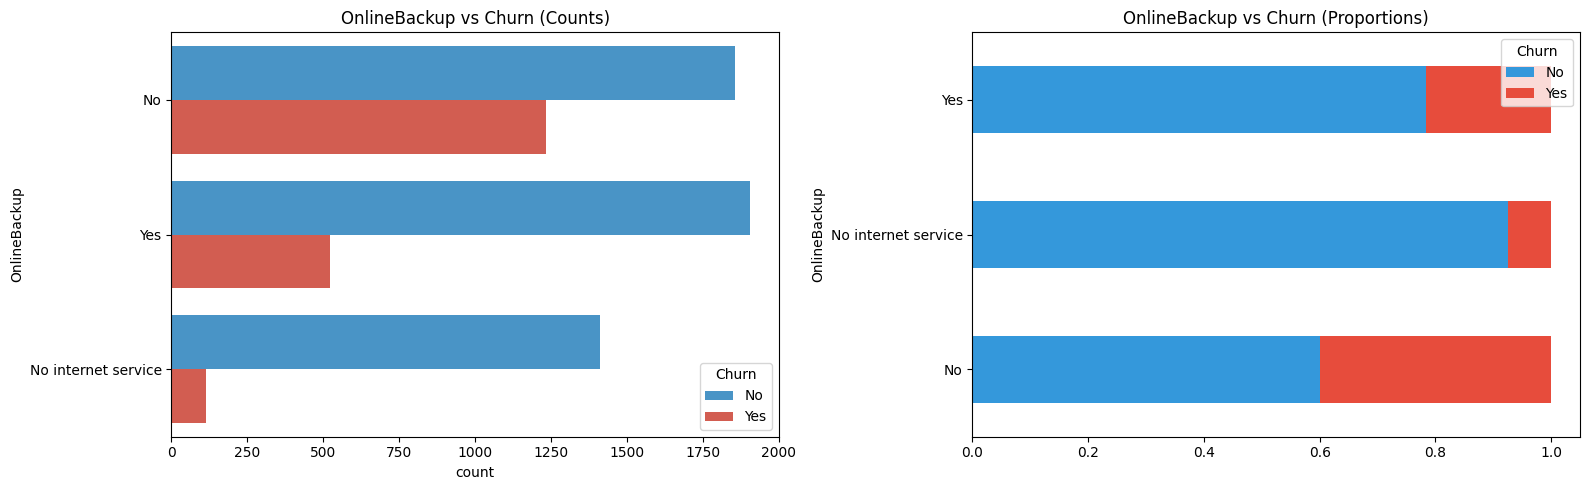

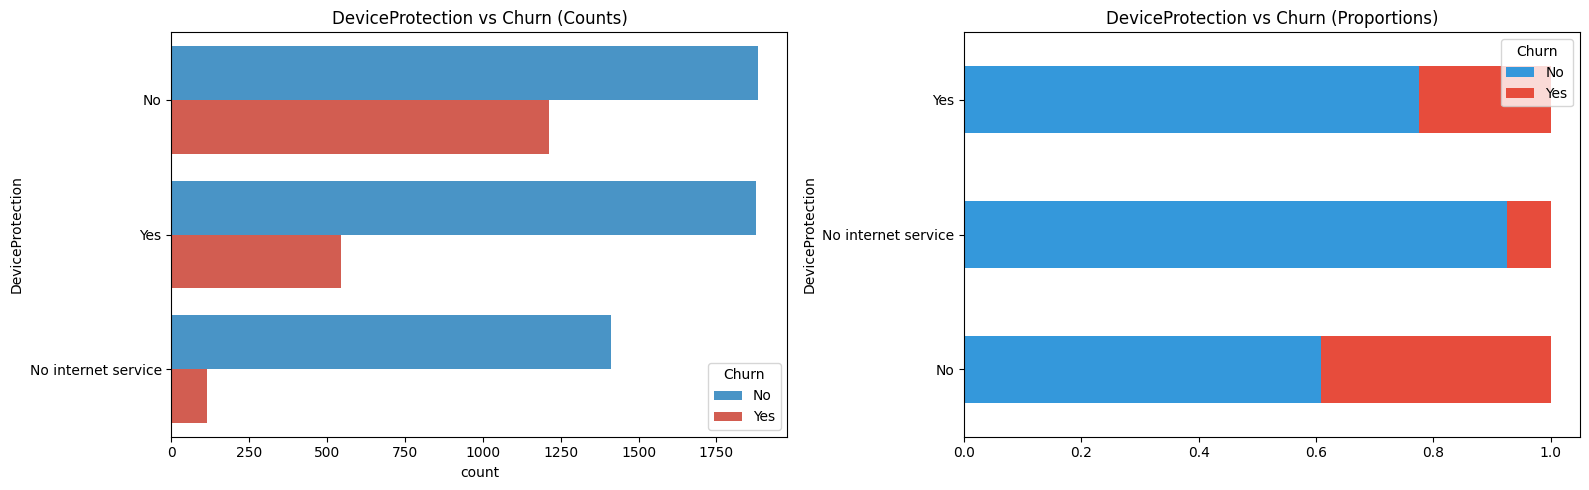

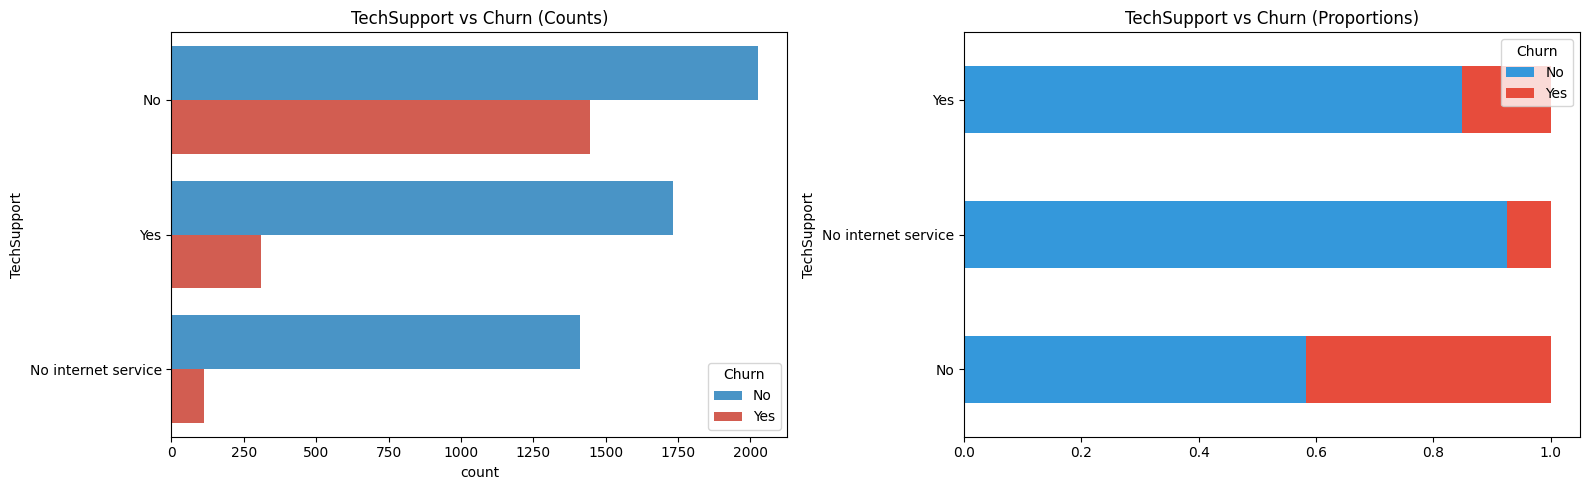

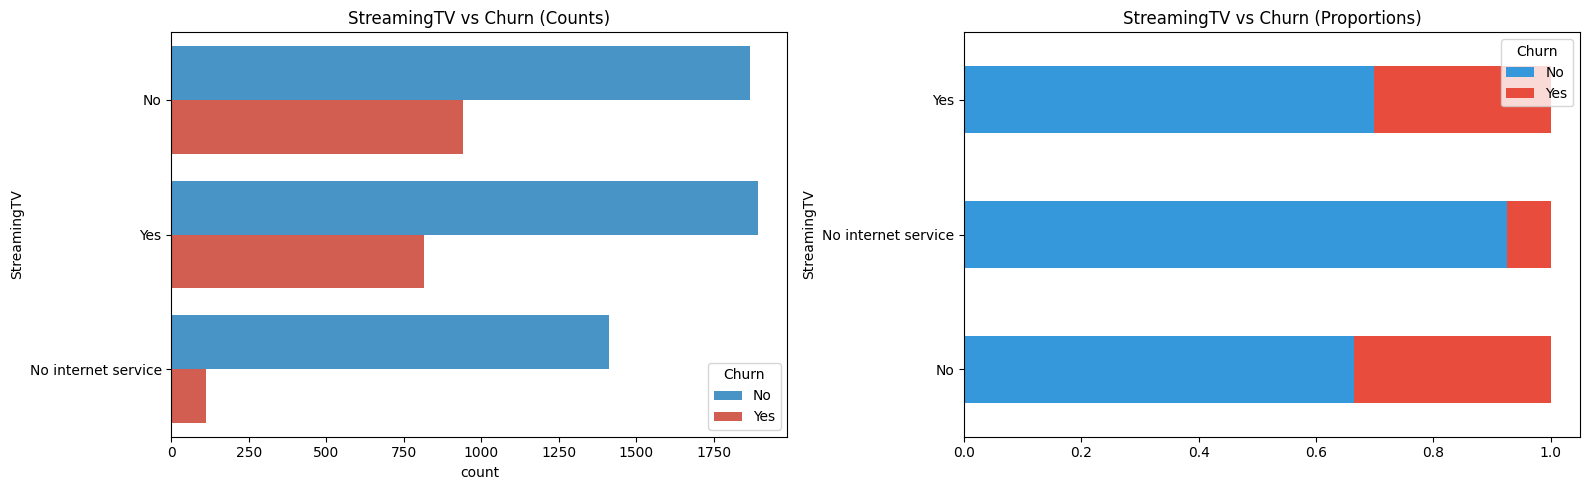

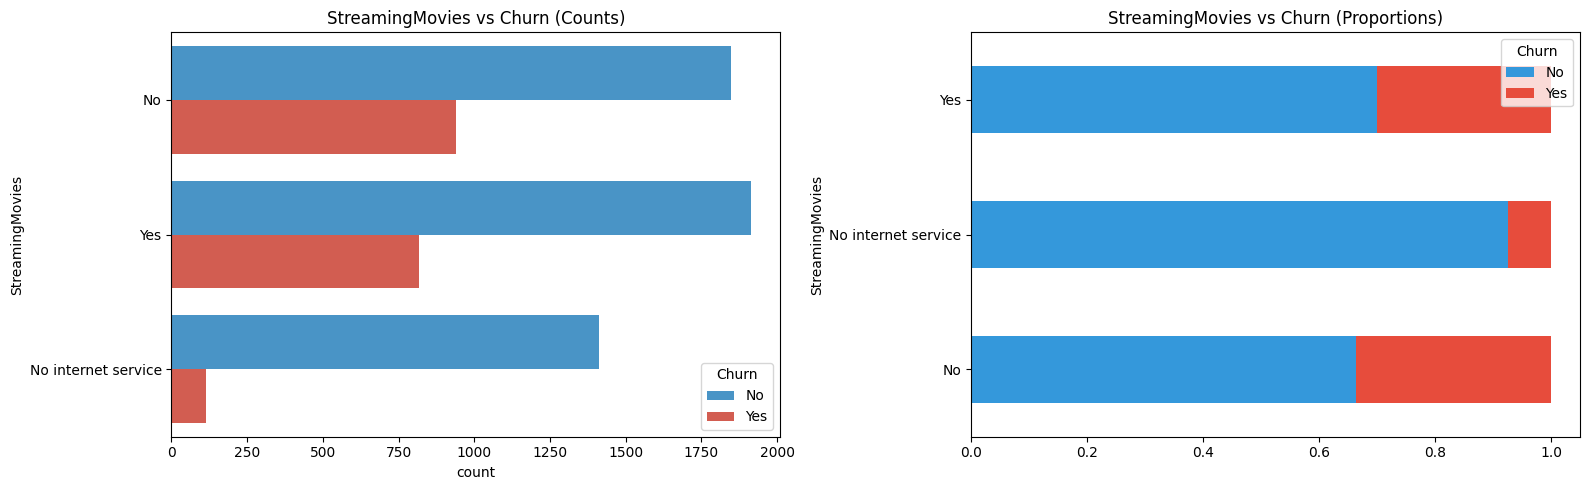

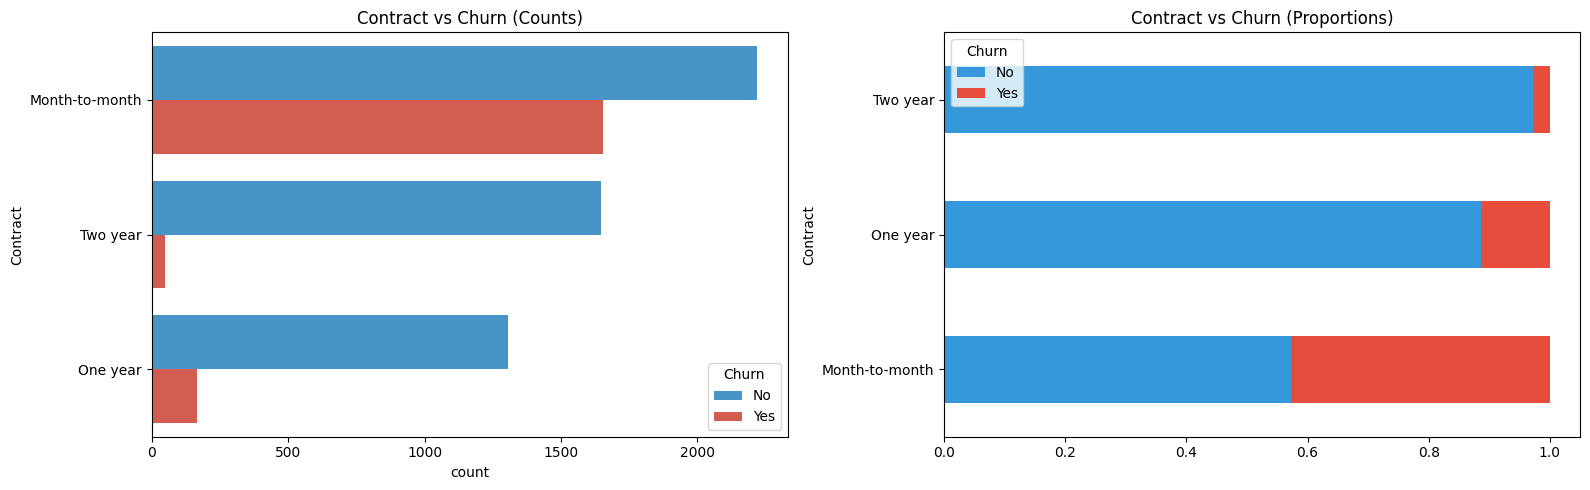

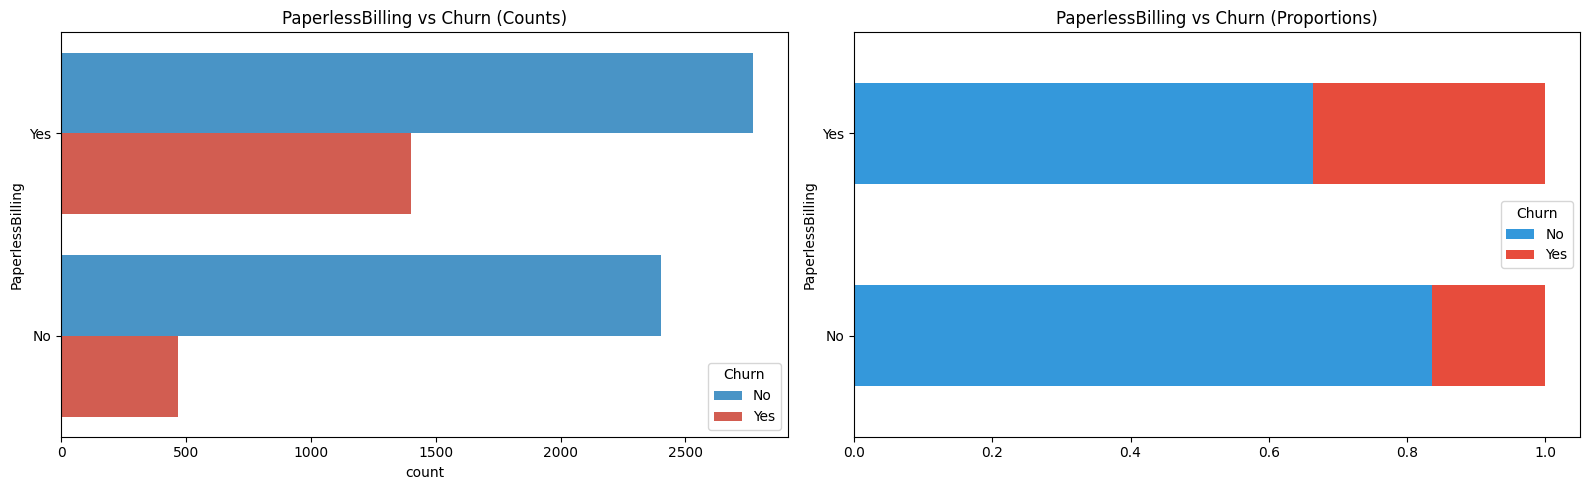

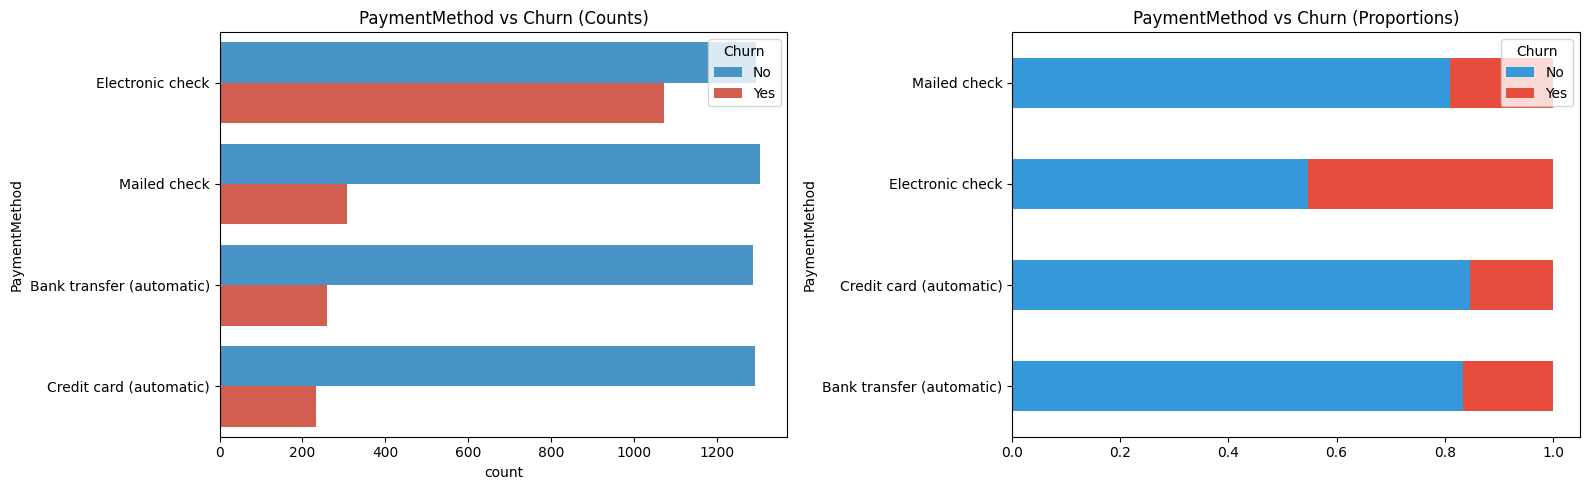

In [45]:
# Count plots and proportion plots for each categorical feature by target
for col in cat_cols:
    fig, axes = plt.subplots(1, 2, figsize=(16, 5))

    # Count plot split by target
    order = df[col].value_counts().index
    sns.countplot(data=df, y=col, hue='Churn', order=order, ax=axes[0],
                  palette=['#3498db', '#e74c3c'])
    axes[0].set_title(f'{col} vs Churn (Counts)')

    # Proportion plot
    ct = pd.crosstab(df[col], df['Churn'], normalize='index')
    ct.plot(kind='barh', stacked=True, ax=axes[1], color=['#3498db', '#e74c3c'])
    axes[1].set_title(f'{col} vs Churn (Proportions)')
    axes[1].legend(title='Churn')

    plt.tight_layout()
    plt.show()

#### Key Patterns

- **Contract**: Month-to-month customers have a very high churn rate (~43%). One-year and two-year contract customers rarely churn. This is the strongest categorical predictor.
- **InternetService**: Fiber optic customers churn the most (~42%). DSL customers churn less. Customers with no internet barely churn. Fiber optic may have quality or pricing issues.
- **PaymentMethod**: Electronic check customers churn the most (~45%). All other payment methods have similar, lower churn rates. This could be because electronic check is the easiest to stop.
- **OnlineSecurity, TechSupport, OnlineBackup**: Customers without these services churn more. Having add-on services increases stickiness.
- **gender**: Almost no difference between male and female churn. Not a useful predictor.
- **SeniorCitizen**: Seniors churn slightly more than non-seniors.


---

## Correlation Heatmap

Correlation measures linear relationships between numeric features.

We check:
1. Which features correlate with each other (multicollinearity, a problem)
2. Relationship between numeric features

For feature vs target correlation, we will encode the target first.

---

#### Pearson vs Spearman

| Type | Measures | When to Use |
|---|---|---|
| Pearson | Linear relationship | Roughly normal data, no extreme outliers |
| Spearman | Monotonic (rank-based) | Outliers, nonlinear but monotonic trends |

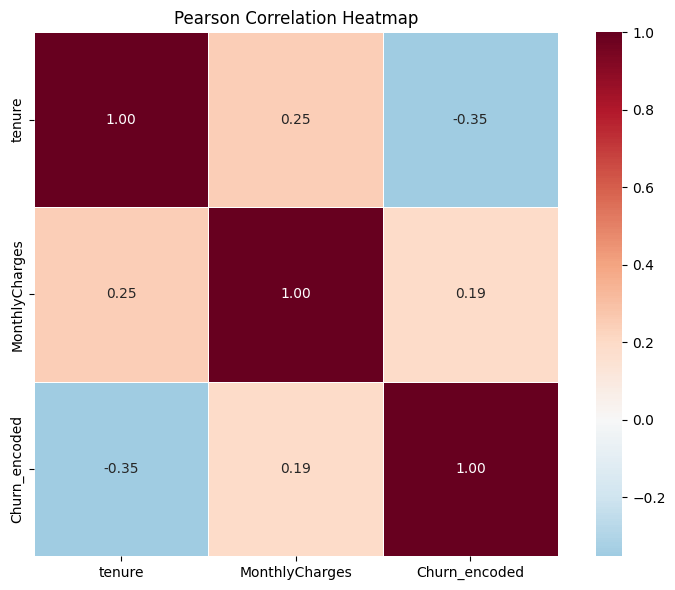

In [18]:
# Encode target for correlation
df_corr = df.copy()
df_corr['Churn_encoded'] = (df_corr['Churn'] == 'Yes').astype(int)

# Correlation matrix
corr_cols = num_cols + ['Churn_encoded']
corr_matrix = df_corr[corr_cols].corr()

# Heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(corr_matrix, annot=True, cmap='RdBu_r', center=0, fmt='.2f',
            square=True, linewidths=0.5)
plt.title('Pearson Correlation Heatmap')
plt.tight_layout()
plt.show()

In [48]:
# Correlation with target ranked
target_corr = corr_matrix['Churn_encoded'].drop('Churn_encoded').sort_values(ascending=False)
print("Correlation with Churn (Pearson):")
for feat, val in target_corr.items():
    direction = "positive" if val > 0 else "negative"
    print(f"  {feat:20s}: {val:+.3f} ({direction})")

Correlation with Churn (Pearson):
  MonthlyCharges      : +0.193 (positive)
  tenure              : -0.352 (negative)


In [47]:
# Multicollinearity check
print("\nHigh correlation pairs (|r| > 0.7):")
found = False
for i in range(len(num_cols)):
    for j in range(i+1, len(num_cols)):
        r = corr_matrix.loc[num_cols[i], num_cols[j]]
        if abs(r) > 0.7:
            print(f"  {num_cols[i]} <-> {num_cols[j]}: {r:.3f}")
            found = True
if not found:
    print("  No highly correlated feature pairs found.")


High correlation pairs (|r| > 0.7):
  No highly correlated feature pairs found.


#### **Key insights**

- **tenure vs Churn**: Shows a negative correlation, indicating that customers with longer tenure are less likely to churn. This aligns with the expectation that long-term customers tend to stay.
- **MonthlyCharges vs Churn**: Displays a positive correlation, suggesting that customers with higher monthly charges are more likely to churn.
- **TotalCharges vs tenure**: Exhibits a strong positive correlation, which is expected since total charges naturally increase as tenure grows. These two variables are closely related and may carry overlapping information.

---

## Outlier Detection

Two methods:

**IQR Method**: A value is an outlier if it falls below Q1 - 1.5*IQR or above Q3 + 1.5*IQR. 

**Z-Score Method**: A value is an outlier if it is more than 3 standard deviations from the mean. Assumes roughly normal distribution.


In [49]:
# IQR Method
print("Outlier Detection: IQR Method")
print("=" * 55)
for col in num_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    outliers = ((df[col] < lower) | (df[col] > upper)).sum()
    pct = (outliers / len(df)) * 100
    print(f"  {col:20s}: {outliers:4d} outliers ({pct:.1f}%)  [Range: {lower:.1f} to {upper:.1f}]")

Outlier Detection: IQR Method
  tenure              :    0 outliers (0.0%)  [Range: -60.0 to 124.0]
  MonthlyCharges      :    0 outliers (0.0%)  [Range: -46.0 to 171.4]


In [50]:
# Z-Score Method
print("Outlier Detection: Z-Score Method (|z| > 3)")
print("=" * 55)
for col in num_cols:
    z_scores = (df[col] - df[col].mean()) / df[col].std()
    outliers = (z_scores.abs() > 3).sum()
    pct = (outliers / len(df)) * 100
    print(f"  {col:20s}: {outliers:4d} outliers ({pct:.1f}%)")

Outlier Detection: Z-Score Method (|z| > 3)
  tenure              :    0 outliers (0.0%)
  MonthlyCharges      :    0 outliers (0.0%)


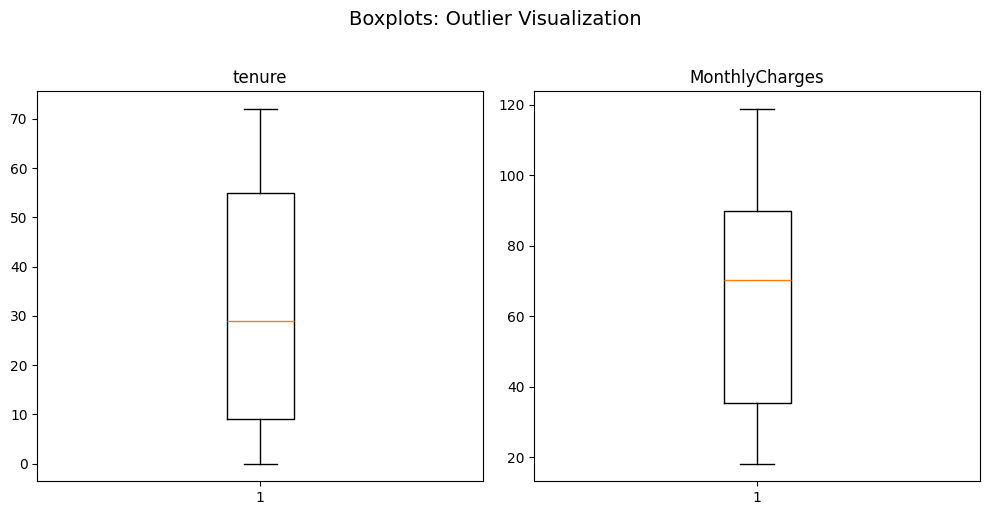

In [51]:
# Visualize outliers with boxplots side by side
fig, axes = plt.subplots(1, len(num_cols), figsize=(5*len(num_cols), 5))

for i, col in enumerate(num_cols):
    axes[i].boxplot(df[col], vert=True)
    axes[i].set_title(col)

plt.suptitle('Boxplots: Outlier Visualization', y=1.02, fontsize=14)
plt.tight_layout()
plt.show()

#### **Observations**

TotalCharges has outliers by IQR method, but these are real values from long-term customers. Not data errors.

For this dataset, we are not removing any outliers because:
- The values are legitimate (actual customer charges)
- Tree-based models handle outliers naturally
- Removing them would lose information about high-value customers

If we were using linear regression, we might apply **winsorization** (capping values at the 1st and 99th percentile) or log transformation.

---

## Skewness and Log Transform

Highly skewed features can hurt linear models because the model gets dominated by extreme values. Log transformation compresses the range and makes the distribution more symmetric.

In [24]:
# Skewness values
print("Skewness of numeric features:")
print("-" * 40)
for col in num_cols:
    skew = df[col].skew()
    label = "Symmetric" if abs(skew) < 0.5 else ("Moderate" if abs(skew) < 1 else "High skew")
    print(f"  {col:20s}: {skew:+.3f}  ({label})")

Skewness of numeric features:
----------------------------------------
  tenure              : +0.240  (Symmetric)
  MonthlyCharges      : -0.221  (Symmetric)


In [25]:
# Log transform for skewed features
# np.log1p handles zeros (log(1+x) instead of log(x))

skewed_cols = [col for col in num_cols if abs(df[col].skew()) > 1]

if skewed_cols:
    for col in skewed_cols:
        fig, axes = plt.subplots(1, 2, figsize=(12, 4))

        # Original
        axes[0].hist(df[col], bins=30, color='#3498db', edgecolor='black', alpha=0.7)
        axes[0].set_title(f'{col} Original (skew={df[col].skew():.2f})')

        # Log transformed
        log_vals = np.log1p(df[col])
        axes[1].hist(log_vals, bins=30, color='#2ecc71', edgecolor='black', alpha=0.7)
        axes[1].set_title(f'{col} Log Transformed (skew={log_vals.skew():.2f})')

        plt.tight_layout()
        plt.show()
else:
    print("No highly skewed features found.")
    print("Showing moderate skew features for comparison:")
    for col in num_cols:
        if abs(df[col].skew()) > 0.3:
            fig, axes = plt.subplots(1, 2, figsize=(12, 4))
            axes[0].hist(df[col], bins=30, color='#3498db', edgecolor='black', alpha=0.7)
            axes[0].set_title(f'{col} Original (skew={df[col].skew():.2f})')
            log_vals = np.log1p(df[col])
            axes[1].hist(log_vals, bins=30, color='#2ecc71', edgecolor='black', alpha=0.7)
            axes[1].set_title(f'{col} Log Transformed (skew={log_vals.skew():.2f})')
            plt.tight_layout()
            plt.show()

No highly skewed features found.
Showing moderate skew features for comparison:


---

## Normality Tests

In [26]:
# Normality tests
print("Normality Tests")
print("=" * 60)
print(f"  {'Feature':20s} {'D\'Agostino stat':>15s} {'p-value':>12s} {'Result':>15s}")
print("  " + "-" * 55)

for col in num_cols:
    sample = df[col].dropna()
    if len(sample) > 5000:
        sample = sample.sample(5000, random_state=42)
    stat, p = normaltest(sample)
    result = "Normal" if p > 0.05 else "Not Normal"
    print(f"  {col:20s} {stat:15.2f} {p:12.6f} {result:>15s}")

Normality Tests
  Feature              D'Agostino stat      p-value          Result
  -------------------------------------------------------
  tenure                      59800.14     0.000000      Not Normal
  MonthlyCharges               7005.86     0.000000      Not Normal


All features fail the normality test. This is expected for two reasons:

1. With large datasets (7000+ rows), even tiny deviations from normality become statistically significant. The test is very sensitive with large samples.

2. Real-world data is almost never perfectly normal. Charges and tenure have natural bounds and skewness.


### T-test: Numeric Features vs Churn

The t-test checks: is the mean of this numeric feature significantly different between the two churn groups?

The math:

t = (mean_group1 - mean_group2) / sqrt(var1/n1 + var2/n2)

Large t means the means are far apart relative to the noise. Small p-value means that difference is real.

In [27]:
# T-test for each numeric feature
print("T-Tests: Numeric Features vs Churn")
print("=" * 65)

ttest_results = []
for col in num_cols:
    group_no = df[df['Churn'] == 'No'][col]
    group_yes = df[df['Churn'] == 'Yes'][col]
    t_stat, p_val = ttest_ind(group_no, group_yes)
    sig = "Significant" if p_val < 0.05 else "Not Significant"
    ttest_results.append([col, t_stat, p_val, sig])
    print(f"  {col:20s}: t = {t_stat:+8.3f}, p = {p_val:.6f}  -> {sig}")

T-Tests: Numeric Features vs Churn
  tenure              : t =  +31.580, p = 0.000000  -> Significant
  MonthlyCharges      : t =  -16.537, p = 0.000000  -> Significant


All numeric features show statistically significant differences between churned and non-churned customers.

- tenure: t is positive and large. Non-churned customers have significantly higher tenure. Strongest numeric predictor.
- MonthlyCharges: t is negative. Churned customers have significantly higher monthly charges.
- TotalCharges: t is positive. Non-churned customers have higher total charges (because they stayed longer).

---

### Chi-Square Test: Categorical Features vs Churn

In [28]:
# Chi-Square for each categorical feature
print("Chi-Square Tests: Categorical Features vs Churn")
print("=" * 70)

chi2_results = []
for col in cat_cols:
    ct = pd.crosstab(df[col], df['Churn'])
    chi2, p_val, dof, expected = chi2_contingency(ct)
    sig = "Significant" if p_val < 0.05 else "Not Significant"
    chi2_results.append([col, chi2, dof, p_val, sig])
    print(f"  {col:20s}: chi2 = {chi2:10.3f}, dof = {dof}, p = {p_val:.6f}  -> {sig}")

Chi-Square Tests: Categorical Features vs Churn
  gender              : chi2 =      0.484, dof = 1, p = 0.486579  -> Not Significant
  SeniorCitizen       : chi2 =    159.426, dof = 1, p = 0.000000  -> Significant
  Partner             : chi2 =    158.733, dof = 1, p = 0.000000  -> Significant
  Dependents          : chi2 =    189.129, dof = 1, p = 0.000000  -> Significant


  PhoneService        : chi2 =      0.915, dof = 1, p = 0.338783  -> Not Significant
  MultipleLines       : chi2 =     11.330, dof = 2, p = 0.003464  -> Significant
  InternetService     : chi2 =    732.310, dof = 2, p = 0.000000  -> Significant
  OnlineSecurity      : chi2 =    849.999, dof = 2, p = 0.000000  -> Significant
  OnlineBackup        : chi2 =    601.813, dof = 2, p = 0.000000  -> Significant
  DeviceProtection    : chi2 =    558.419, dof = 2, p = 0.000000  -> Significant
  TechSupport         : chi2 =    828.197, dof = 2, p = 0.000000  -> Significant
  StreamingTV         : chi2 =    374.204, dof = 2, p = 0.000000  -> Significant
  StreamingMovies     : chi2 =    375.661, dof = 2, p = 0.000000  -> Significant
  Contract            : chi2 =   1184.597, dof = 2, p = 0.000000  -> Significant
  PaperlessBilling    : chi2 =    258.278, dof = 1, p = 0.000000  -> Significant
  PaymentMethod       : chi2 =    648.142, dof = 3, p = 0.000000  -> Significant


#### Results Interpretation

Most categorical features are significantly associated with churn. But a few are not significant (or barely significant), meaning they do not help distinguish churners from non-churners.

The strongest associations (highest chi2) will be features like Contract, InternetService, and PaymentMethod. These matched what we saw visually in the bivariate analysis.

gender likely shows no significant association, confirming our earlier observation that churn rates are similar for males and females.

---

In [52]:
# Combined Summary Table
print()
print("=" * 70)
print("FULL STATISTICAL TESTS SUMMARY")
print("=" * 70)

print("\nNumeric Features (T-test):")
print(f"  {'Feature':20s} {'T-stat':>10s} {'p-value':>12s} {'Result':>15s}")
print("  " + "-" * 58)
for row in ttest_results:
    print(f"  {row[0]:20s} {row[1]:+10.3f} {row[2]:12.6f} {row[3]:>15s}")

print("\nCategorical Features (Chi-Square):")
print(f"  {'Feature':20s} {'Chi2':>10s} {'dof':>5s} {'p-value':>12s} {'Result':>15s}")
print("  " + "-" * 63)
for row in chi2_results:
    print(f"  {row[0]:20s} {row[1]:10.3f} {row[2]:5d} {row[3]:12.6f} {row[4]:>15s}")


FULL STATISTICAL TESTS SUMMARY

Numeric Features (T-test):
  Feature                  T-stat      p-value          Result
  ----------------------------------------------------------
  tenure                  +31.580     0.000000     Significant
  MonthlyCharges          -16.537     0.000000     Significant

Categorical Features (Chi-Square):
  Feature                    Chi2   dof      p-value          Result
  ---------------------------------------------------------------
  gender                    0.484     1     0.486579 Not Significant
  SeniorCitizen           159.426     1     0.000000     Significant
  Partner                 158.733     1     0.000000     Significant
  Dependents              189.129     1     0.000000     Significant
  PhoneService              0.915     1     0.338783 Not Significant
  MultipleLines            11.330     2     0.003464     Significant
  InternetService         732.310     2     0.000000     Significant
  OnlineSecurity          849.999   

---

## Multivariate Analysis

Looking at 3 or more variables together. This catches patterns that bivariate misses.

For example, MonthlyCharges alone might show a weak relationship with churn. But MonthlyCharges combined with Contract type might reveal: high monthly charges with month-to-month contract leads to very high churn.

---

### Pairplot

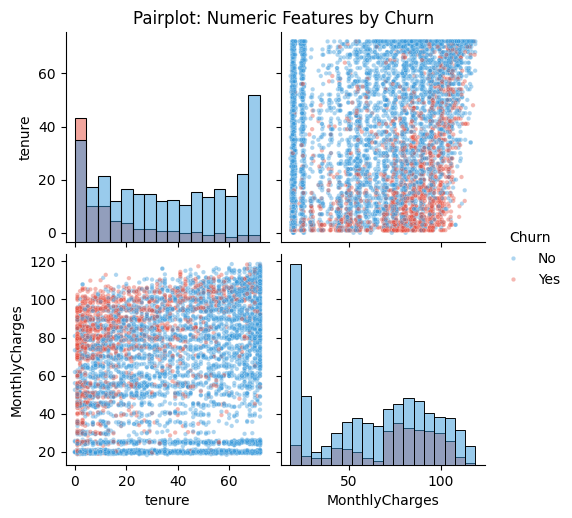

In [30]:
# Pairplot on numeric features colored by target
pair_df = df[num_cols + ['Churn']].copy()

sns.pairplot(pair_df, hue='Churn', palette=['#3498db', '#e74c3c'],
             diag_kind='hist', plot_kws={'alpha': 0.4, 's': 10})
plt.suptitle('Pairplot: Numeric Features by Churn', y=1.02)
plt.show()

#### Reading a Pairplot

- **Diagonal**: Distribution of each feature split by class. If the two histograms look different, that feature is individually useful.
- **Off-diagonal**: Scatter of two features colored by class. If colors form separate clusters, those two features together can help.

From this pairplot, tenure vs MonthlyCharges shows some separation. Low-tenure + high-charges customers (red) cluster in the top-left area. This confirms our bivariate finding.

---

### Grouped Aggregation

In [31]:
# Mean charges grouped by Contract type and Churn
print("Mean MonthlyCharges by Contract and Churn:")
print(df.groupby(['Contract', 'Churn'])['MonthlyCharges'].mean().round(2).unstack())

Mean MonthlyCharges by Contract and Churn:
Churn              No    Yes
Contract                    
Month-to-month  61.46  73.02
One year        62.51  85.05
Two year        60.01  86.78


In [32]:
# Mean tenure grouped by InternetService and Churn
print("\nMean tenure by InternetService and Churn:")
print(df.groupby(['InternetService', 'Churn'])['tenure'].mean().round(1).unstack())


Mean tenure by InternetService and Churn:
Churn              No   Yes
InternetService            
DSL              37.2  14.1
Fiber optic      42.1  20.2
No               32.3   8.2


In [33]:
# Churn rate by Contract + InternetService combination
print("\nChurn rate by Contract + InternetService:")
ct = pd.crosstab([df['Contract'], df['InternetService']], df['Churn'], normalize='index')
ct.columns = ['No_Churn_%', 'Yes_Churn_%']
print((ct * 100).round(1))


Churn rate by Contract + InternetService:
                                No_Churn_%  Yes_Churn_%
Contract       InternetService                         
Month-to-month DSL                    67.8         32.2
               Fiber optic            45.4         54.6
               No                     81.1         18.9
One year       DSL                    90.7          9.3
               Fiber optic            80.7         19.3
               No                     97.5          2.5
Two year       DSL                    98.1          1.9
               Fiber optic            92.8          7.2
               No                     99.2          0.8


#### Key Multivariate Patterns

- Month-to-month + Fiber optic: highest churn rate. These customers pay high prices on flexible contracts, making it easy and tempting to leave.
- Two-year contract + any internet: lowest churn. Long commitment keeps customers even if they use fiber optic.
- Churned fiber optic customers have lower average tenure, meaning they leave faster than DSL or no-internet customers.

These insights are more actionable than single-variable findings. A business could target "month-to-month fiber optic" customers specifically with retention offers.

---

## PCA (Principal Component Analysis) Visualization

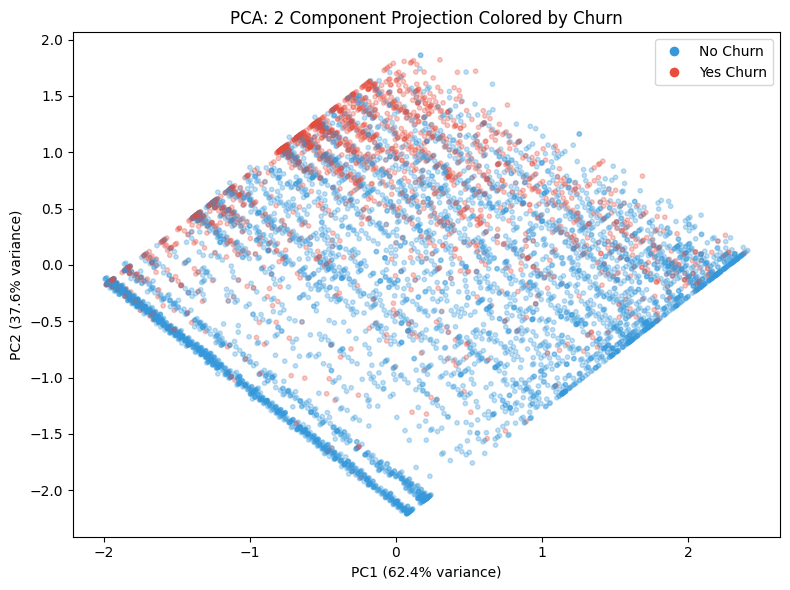

Variance explained by PC1: 62.4%
Variance explained by PC2: 37.6%
Total variance explained: 100.0%


In [34]:
# PCA requires numeric data, so we scale the numeric features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(df[num_cols])

# PCA to 2 components
pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_scaled)

# Plot
plt.figure(figsize=(8, 6))
colors = ['#3498db' if c == 'No' else '#e74c3c' for c in df['Churn']]
plt.scatter(X_pca[:, 0], X_pca[:, 1], c=colors, alpha=0.3, s=10)
plt.xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.1f}% variance)')
plt.ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.1f}% variance)')
plt.title('PCA: 2 Component Projection Colored by Churn')

from matplotlib.lines import Line2D
legend = [Line2D([0], [0], marker='o', color='w', markerfacecolor='#3498db', label='No Churn', markersize=8),
          Line2D([0], [0], marker='o', color='w', markerfacecolor='#e74c3c', label='Yes Churn', markersize=8)]
plt.legend(handles=legend)
plt.tight_layout()
plt.show()

print(f"Variance explained by PC1: {pca.explained_variance_ratio_[0]*100:.1f}%")
print(f"Variance explained by PC2: {pca.explained_variance_ratio_[1]*100:.1f}%")
print(f"Total variance explained: {pca.explained_variance_ratio_.sum()*100:.1f}%")

#### Interpretation

If the red and blue points overlap heavily, the numeric features alone are not enough to linearly separate the classes. This means:
- We need categorical features too (which PCA did not use here)
- We likely need nonlinear models (Random Forest, Gradient Boosting)
- The problem is inherently complex

If there is some partial separation, linear models might work but with limited accuracy.

---

## Class Imbalance Handling

We saw earlier that 73% of data is No Churn and 27% is Yes Churn. We need to handle this before modeling.


In [35]:
# Approach 1: Class Weights (built into sklearn)
# This is the most common approach. Most classifiers support class_weight='balanced'.

# How it works internally:
majority_count = (df['Churn'] == 'No').sum()
minority_count = (df['Churn'] == 'Yes').sum()
total = len(df)
n_classes = 2

weight_no = total / (n_classes * majority_count)
weight_yes = total / (n_classes * minority_count)

print("Class Weight Calculation:")
print(f"  Weight for 'No':  {weight_no:.3f}")
print(f"  Weight for 'Yes': {weight_yes:.3f}")
print()
print("The minority class (Yes) gets a higher weight.")
print("This forces the model to pay more attention to churners.")
print()
print("In sklearn, just set: class_weight='balanced'")
print("The library calculates these weights automatically.")

Class Weight Calculation:
  Weight for 'No':  0.681
  Weight for 'Yes': 1.884

The minority class (Yes) gets a higher weight.
This forces the model to pay more attention to churners.

In sklearn, just set: class_weight='balanced'
The library calculates these weights automatically.


In [36]:
# Approach 2: SMOTE (Synthetic Minority Oversampling)
# SMOTE creates synthetic samples by interpolating between existing minority samples.

# How it works:
# 1. Pick a minority sample
# 2. Find its k nearest neighbors (also minority)
# 3. Create a new sample somewhere between the original and a random neighbor
# 4. Repeat until classes are balanced

# Code (requires imbalanced-learn library):
# from imblearn.over_sampling import SMOTE
# smote = SMOTE(random_state=42)
# X_train_smote, y_train_smote = smote.fit_resample(X_train, y_train)

print("SMOTE Rules:")
print("  1. Apply ONLY to training data, never test data")
print("  2. Apply AFTER train-test split")
print("  3. Apply BEFORE model training")
print("  4. The test set must remain untouched to give honest evaluation")

SMOTE Rules:
  1. Apply ONLY to training data, never test data
  2. Apply AFTER train-test split
  3. Apply BEFORE model training
  4. The test set must remain untouched to give honest evaluation


In [37]:
# Approach 3: Undersampling
# Randomly remove majority class samples until balanced.

# Code:
# from imblearn.under_sampling import RandomUnderSampler
# rus = RandomUnderSampler(random_state=42)
# X_train_under, y_train_under = rus.fit_resample(X_train, y_train)

print("Undersampling Trade-off:")
print(f"  Current majority samples: {majority_count}")
print(f"  Current minority samples: {minority_count}")
print(f"  After undersampling, both classes would have: {minority_count}")
print(f"  Data lost: {majority_count - minority_count} samples ({(majority_count - minority_count)/total*100:.1f}%)")
print()
print("That is a LOT of data to throw away. Use undersampling only when:")
print("  - Dataset is very large (100K+ rows)")
print("  - Or combined with SMOTE (SMOTE + undersampling together)")

Undersampling Trade-off:
  Current majority samples: 5174
  Current minority samples: 1869
  After undersampling, both classes would have: 1869
  Data lost: 3305 samples (46.9%)

That is a LOT of data to throw away. Use undersampling only when:
  - Dataset is very large (100K+ rows)
  - Or combined with SMOTE (SMOTE + undersampling together)


## Key Insights Summary

1. **TotalCharges had hidden missing values** stored as blank spaces, not NaN. isnull() alone would not catch them. Always inspect unique values and data types.

2. **Class imbalance is moderate** (73/27 split, 2.7:1 ratio). Accuracy alone is misleading. Use F1 or ROC-AUC instead.

3. **Strongest predictors of churn**: Contract type (month-to-month = high churn), InternetService (fiber optic = high churn), tenure (low tenure = high churn), MonthlyCharges (high charges = high churn).

4. **Gender has no significant impact** on churn. Male and female churn rates are almost identical.

5. **Tenure is bimodal**: customers either leave early or stay for a very long time. Few are in the middle. This suggests the first few months are critical for retention.

6. **TotalCharges is highly correlated with tenure** (expected, since charges accumulate over time). One of them is partially redundant.

7. **The riskiest customer segment** is month-to-month contract + fiber optic internet. They have the highest churn rate. This is an actionable business insight.

8. **Add-on services reduce churn**: customers with OnlineSecurity, TechSupport, OnlineBackup, etc. are less likely to leave. These services increase stickiness.

9. **Electronic check payment** is associated with higher churn. All other payment methods have similar, lower churn rates.

10. **Statistical tests confirmed visual patterns**: all features except gender showed significant association with churn (t-test for numeric, chi-square for categorical).